In [ ]:
import os, pickle, time
from datetime import datetime
from pathlib import Path

# ── CPU thread limiting — keeps M1 MacBook responsive during overnight run ──
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import torch
torch.set_num_threads(4)

try:
    import psutil
    psutil.Process(os.getpid()).nice(10)
    _nice_status = "nice=10 (below normal)"
except ImportError:
    _nice_status = "psutil not installed (run: pip install psutil)"

# ── Checkpoint + logging helpers ────────────────────────────────────────────
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

def save_checkpoint(name: str, data) -> None:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    path = CHECKPOINT_DIR / f"{name}_{ts}.pkl"
    with open(path, "wb") as f:
        pickle.dump(data, f)
    log(f"Checkpoint saved → {path.name}")

def log(msg: str) -> None:
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] {msg}", flush=True)

# ── Runtime tracking ─────────────────────────────────────────────────────────
pipeline_start_time = time.time()

# ── Confirmation ─────────────────────────────────────────────────────────────
log("=" * 55)
log("Overnight run — CPU optimization active")
log(f"  OMP_NUM_THREADS   = {os.environ['OMP_NUM_THREADS']}")
log(f"  MKL_NUM_THREADS   = {os.environ['MKL_NUM_THREADS']}")
log(f"  torch num_threads = {torch.get_num_threads()}")
log(f"  process priority: {_nice_status}")
log(f"  checkpoint dir:   {CHECKPOINT_DIR.resolve()}")
log("=" * 55)


# Overnight Run Configuration

## CPU Optimization
- **Thread limit:** OMP=4, MKL=4, PyTorch=4 — leaves cores free for other apps
- **Process priority:** nice=10 (below normal on macOS) — system stays responsive for Docs/Meet

## Hyperparameter Grids (Lean)

| Model | Configs | Epochs×Folds | Est. time |
|-------|---------|--------------|-----------|
| LogReg | 3 (C ∈ {0.1, 1, 10}) | 5-fold CV | ~3 min |
| MLP | 6 (2 hidden × 3 α) | 5-fold CV | ~15 min |
| GCN | 12 (3 hidden × 2 lr × 2 drop) | 80 ep × 5 folds | ~2 hr |
| GAT | 12 (2 hidden × 2 heads × 3 lr) | 80 ep × 5 folds | ~3 hr |
| Graph ablations | 4 strategies × 4 configs | 60 ep × 5 folds | ~2 hr |
| Depth ablation | 2 depths × 2 configs | 60 ep × 5 folds | ~40 min |

**Estimated total: ~8 hours on M1 CPU**

## Checkpoints
Saved to `checkpoints/` after: baseline training, artifact analysis, Fisher z, graph ablations, oversmoothing.

## System Impact
With 4-thread cap + nice=10 priority, the laptop remains usable for light browsing, Google Docs, and Meet calls during training.


# CS156: Pipeline - Second Draft

**Can You Diagnose Autism From Brain Noise?**

There’s a persistent idea in computational neuroscience that you can look at a brain scan and read *something* meaningful: a diagnosis, a trait, or a difference in how someone thinks. It’s a compelling idea. It’s also, at best, an approximation.

This project starts from a deliberately uncomfortable question:

> If you take a noisy, indirect measurement of brain activity and reduce it to correlations between ~200 regions, is there actually enough signal left to distinguish individuals with Autism Spectrum Disorder (ASD) from controls?

The data used here are resting-state fMRI time series, summarized as functional connectivity matrices. In practice, this means:
- we are not observing neural activity directly  
- we are not measuring interactions between regions  
- we are measuring statistical co-variation under a long chain of preprocessing assumptions  

So the object we feed into our models is already several steps removed from anything we might confidently call “brain function.”

Given that, the goal of this project is not to build a diagnostic tool, but rather to test how different modeling assumptions behave when applied to this representation.

Each subject is represented as a connectivity matrix derived from ROI time series (`rois_cc200`). From there, we ask a simple but pointed question:

> Does treating the brain as a graph actually help, or are we just adding structure to noise?

To answer this, we compare four approaches:

* Logistic Regression on flattened connectivity features  
* A multilayer perceptron (MLP) on the same representation  
* A graph convolutional network (GCN) that assumes connectivity structure matters  
* A graph attention network (GAT) that learns which connections to emphasize  

All models operate on the same underlying data, allowing differences in performance to reflect model assumptions rather than differences in input.

If graph-based models outperform simpler baselines, that suggests there is meaningful relational structure in the data. If they do not, it raises a more uncomfortable possibility: that increasing model sophistication does not recover signal that may not be there to begin with.

The notebook proceeds as follows:

1. Load and verify the curated dataset  
2. Construct functional connectivity matrices  
3. Prepare inputs for each modeling approach  
4. Train and evaluate models under consistent conditions  
5. Compare results and analyze differences  

The aim is not to settle whether functional connectivity can diagnose ASD, but to probe how far this representation can be pushed—and where it breaks down.

# Data

The dataset is derived from the ABIDE preprocessed repository (FCP-INDI), using derivatives generated by the CPAC pipeline with the `filt_global` preprocessing strategy and the CC200 functional parcellation. Each subject is represented by ROI-level time series extracted from resting-state fMRI data.

Subjects are included based on:
- Valid phenotypic entry (`FILE_ID != "no_filename"`)
- Diagnostic label restricted to ASD and control groups (`DX_GROUP ∈ {1, 2}`)
- Availability of corresponding CC200 time series files

Subjects with missing files, invalid dimensions, or failed loading are excluded. The final dataset contains 1035 subjects, split into training (828) and test (207) sets using stratified sampling over diagnosis labels.


## Preprocessing and CC200 representation

All imaging data are derived from the ABIDE Preprocessed derivatives hosted on the FCP-INDI Amazon S3 bucket. We specifically use:

- Pipeline: C-PAC (`cpac`)
- Strategy: global signal regression with band-pass filtering (`filt_global`)
- Derivative: CC200 ROI time series (`rois_cc200`)

Each subject is identified by a unique `FILE_ID`, which is used to retrieve precomputed ROI time series stored as `.1D` files.

The input to our models consists of precomputed ROI time series extracted using the Craddock 200 (CC200) functional parcellation. Each subject’s data is represented as a matrix:

$$
[
X \in \mathbb{R}^{T \times 200}
]
$$

where rows correspond to time points and columns correspond to ROIs.

Time series orientation is standardized such that inputs are reshaped to \(T \times 200\) if required. No additional temporal preprocessing (e.g., trimming of initial volumes or additional filtering) is applied beyond the ABIDE-provided derivatives.

No additional per-ROI normalization or z-scoring is performed prior to connectivity estimation.


# Feature Construction

Functional Connectivity (FC) is computed per subject as the pairwise Pearson correlation between all ROI time series, producing a symmetric connectivity matrix:

$$
[
\text{FC}_{ij} = \mathrm{corr}(X_i, X_j)
]
$$ 

To stabilize variance and improve statistical properties, FC matrices are transformed using the Fisher z-transform:

$$
[
Z = \operatorname{arctanh}(R)
]
$$

Prior to transformation, correlation values are clipped to $(-1 + \epsilon, 1 - \epsilon)$ to ensure numerical stability. After transformation:
- NaN and infinite values are replaced with zero
- Diagonal entries are set to zero

The resulting Fisher z-transformed FC matrix serves as the shared representation for all downstream models.


## Matrix Representation

Each FC matrix is vectorized by extracting the upper triangular portion (excluding the diagonal), yielding a feature vector of size:

$$
[
\frac{200 \cdot 199}{2} = 19{,}900
]
$$

These features are standardized using z-score normalization (fit on training data only).

This representation is used for classical machine learning models (Logistic Regression and MLP).

## Graph Representation

Each subject is represented as a graph constructed from its FC matrix.

### Graph construction
- Nodes correspond to ROIs (200 total)
- For each node, edges are formed to the top \(k = 10\) ROIs with highest absolute FC magnitude
- Edge selection is based on connectivity strength \(|Z_{ij}|\)
- The graph is symmetrized to form an undirected structure
- Self-loops are excluded

This produces a sparse k-nearest-neighbor graph over functional connectivity structure.

### Edge definition
Edges encode connectivity structure only and are treated as unweighted. Correlation values are not used as edge weights during message passing.


### Node features

Each node is represented by its corresponding FC connectivity profile:

$$
[
x_i = Z_{i,:}
]
$$

i.e., the $(i)$-th row of the Fisher z-transformed FC matrix.

Node features are normalized per node using z-score normalization:

$$
[
x_i \leftarrow \frac{x_i - \mu_i}{\sigma_i}
]
$$

where $(\mu_i)$ and $(\sigma_i)$ are the mean and standard deviation of the $(i)$-th node’s feature vector. This representation introduces some redundancy between node features and graph structure, as both are derived from the same connectivity matrix. However, the graph structure is derived heuristically from correlation magnitude rather than known anatomical connectivity, which may limit the effectiveness of graph-based inductive biases. 

## Key methodological notes

- Fisher z-transform is applied consistently across all representations
- Graph topology is determined by connectivity magnitude, not sign
- GNN models operate on unweighted graphs, with structure derived from FC
- Both ML and GNN models are based on the same underlying FC representation
- No dimensionality reduction (e.g., PCA) is applied
- No additional temporal preprocessing is performed beyond ABIDE derivatives

In [ ]:
# Load time-series data and compute Fisher z-transformed functional connectivity matrices
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

base_dir = Path("data") / "abide_fmri"
ts_dir = base_dir / "timeseries"
fc_dir = base_dir / "connectivity_matrices"

print("[INIT] Ensuring output directory exists...")
fc_dir.mkdir(parents=True, exist_ok=True)

subjects_path = base_dir / "subjects_clean.csv"

def fisher_z_transform(corr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Apply Fisher z-transform safely to correlation matrix."""
    clipped = np.clip(corr, -1 + eps, 1 - eps)
    return np.arctanh(clipped)

# Step 1: Load subject list from CSV or filesystem
print("[STEP 1] Getting subject list...")

if subjects_path.exists():
    print("  -> Reading CSV")
    subjects_df = pd.read_csv(subjects_path)
    print("  -> CSV loaded")

    file_ids = subjects_df["FILE_ID"].dropna().astype(str).drop_duplicates().tolist()
    print("  -> Extracted FILE_IDs")
else:
    print("  -> No CSV found, scanning timeseries folder")
    file_ids = sorted(p.stem for p in ts_dir.glob("*.1D"))

print(f"[STEP 1 DONE] {len(file_ids)} subjects")

valid_ids = []
failed_ids = []
skipped_ids = []
roi_count = None

# Step 2: Process each subject's time series and compute functional connectivity
print("[STEP 2] Starting processing loop...")

for i, fid in enumerate(tqdm(file_ids, desc="Processing")):
    ts_path = ts_dir / f"{fid}.1D"
    fc_path = fc_dir / f"{fid}.npy"

    # Skip subjects whose connectivity matrices already exist
    if fc_path.exists():
        skipped_ids.append(fid)
        valid_ids.append(fid)
        continue

    if not ts_path.exists():
        print(f"[WARN] Missing file: {fid}")
        failed_ids.append(fid)
        continue

    try:
        ts = np.loadtxt(ts_path)

        if ts.ndim != 2:
            print(f"[WARN] Bad shape (ndim) for {fid}: {ts.ndim}")
            failed_ids.append(fid)
            continue

        # Ensure time series is (time_points, 200_ROIs) format
        if ts.shape[1] == 200:
            pass
        elif ts.shape[0] == 200:
            ts = ts.T
            print(f"[INFO] Transposed: {fid}")
        else:
            print(f"[WARN] Unexpected shape for {fid}: {ts.shape}")
            failed_ids.append(fid)
            continue

        # Compute Pearson correlation between ROI time series
        corr = np.corrcoef(ts, rowvar=False)

        # Apply Fisher z-transform immediately after correlation computation
        z = fisher_z_transform(corr)
        z = np.nan_to_num(z).astype(np.float32)  # Replace NaN/inf with 0 and convert to float32
        np.fill_diagonal(z, 0)  # Remove self-loops

        if roi_count is None:
            roi_count = z.shape[0]
            print(f"[INFO] ROI count set to {roi_count}")

        if z.shape != (roi_count, roi_count):
            print(f"[WARN] Shape mismatch for {fid}: {z.shape}")
            failed_ids.append(fid)
            continue

        np.save(fc_path, z)
        valid_ids.append(fid)

    except Exception as e:
        print(f"[ERROR] Failed {fid}: {e}")
        failed_ids.append(fid)

print("[STEP 2 DONE] Processing finished")

# Step 3: Create index file linking FILE_IDs to their connectivity matrices and labels
print("[STEP 3] Building index...")

index_df = pd.DataFrame({"FILE_ID": valid_ids})

if subjects_path.exists():
    subjects_clean = subjects_df[subjects_df["FILE_ID"].isin(valid_ids)].copy()
    subjects_clean.to_csv(base_dir / "subjects_with_fc.csv", index=False)

    index_df = index_df.merge(
        subjects_clean[["FILE_ID", "DX_GROUP"]],
        on="FILE_ID",
        how="left"
    )

index_df.to_csv(base_dir / "connectivity_index.csv", index=False)

# Summary of processing results
print("\n--- Summary ---")
print(f"Processed new: {len(valid_ids) - len(skipped_ids)}")
print(f"Skipped: {len(skipped_ids)}")
print(f"Failed: {len(failed_ids)}")

if roi_count is not None:
    print(f"Matrix shape: ({roi_count}, {roi_count})")

if failed_ids:
    print("Example failures:", failed_ids[:10])

In [ ]:
# Convert Fisher z-transformed connectivity matrices to sparse PyG graph objects with unweighted top-k edge selection
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
from torch_geometric.data import Data

base_dir = Path("data") / "abide_fmri"
fc_dir = base_dir / "connectivity_matrices"
index_path = base_dir / "connectivity_index.csv"
pyg_dir = base_dir / "pyg"
pyg_dir.mkdir(parents=True, exist_ok=True)

TOP_K = 10

def matrix_to_topk_edge_index(adj: np.ndarray, k: int = 10):
    """Extract unweighted top-k edges per node from adjacency matrix.
    Keeps symmetric edges (undirected graph); self-loops removed.
    Returns edge_index (2 x num_edges).
    """
    n = adj.shape[0]
    a = adj.copy().astype(np.float32)
    np.fill_diagonal(a, 0.0)

    edges = set()
    for i in range(n):
        row = a[i]

        # Select top-k neighbors by absolute connectivity magnitude for this node
        valid_idx = np.where(np.abs(row) > 0)[0]
        if len(valid_idx) >= k:
            idx = valid_idx[np.argsort(np.abs(row[valid_idx]))[-k:]]
        else:
            idx = valid_idx

        for j in idx:
            if i == j:
                continue
            u, v = sorted((i, j))
            edges.add((u, v))

    if not edges:
        return torch.empty((2, 0), dtype=torch.long)

    edge_list = []

    # Add bidirectional edges for undirected graph representation
    for (u, v) in edges:
        edge_list.append([u, v])
        edge_list.append([v, u])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# Load subject index and build graph objects
index_df = pd.read_csv(index_path)
label_map = {1: 1, 2: 0}  # DX_GROUP: 1=ASD -> 1, 2=Control -> 0

graphs = []
skipped = []

for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Building graphs"):
    fid = str(row["FILE_ID"])
    y_raw = row.get("DX_GROUP", np.nan)

    mat_path = fc_dir / f"{fid}.npy"
    if not mat_path.exists():
        skipped.append(fid)
        continue

    # Matrices are already Fisher z-transformed in the FC construction cell.
    adj = np.load(mat_path)

    if adj.ndim != 2 or adj.shape[0] != adj.shape[1]:
        skipped.append(fid)
        continue

    adj = np.nan_to_num(adj).astype(np.float32)
    np.fill_diagonal(adj, 0.0)

    # Unweighted sparse structure via top-k selection.
    edge_index = matrix_to_topk_edge_index(adj, k=TOP_K)
    assert edge_index.max() < adj.shape[0]

    # Node features: full connectivity profile (200-dim vector per ROI, normalized)
    x = torch.tensor(adj, dtype=torch.float32)
    x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
    assert x.shape == (adj.shape[0], adj.shape[1])

    data = Data(
        x=x,
        edge_index=edge_index,
        y=None,
        file_id=fid
    )

    if pd.notna(y_raw):
        data.y = torch.tensor([label_map[int(y_raw)]], dtype=torch.long)

    graphs.append(data)

# Save graph list to disk
out_path = pyg_dir / f"graphs_top{TOP_K}.pt"
torch.save(graphs, out_path)

print(f"Saved {len(graphs)} graphs -> {out_path}")
print(f"Skipped: {len(skipped)}")

if graphs:
    g = graphs[0]
    print(f"Graph sanity: nodes={g.num_nodes}, edges={g.edge_index.shape[1]}, unweighted graph used")

# Splitting the Data

## Site-Holdout Split Strategy

To evaluate **true generalization to unseen acquisition sites**, subjects are assigned entirely by site — no subject from a test site appears in training.

| Role | Sites | N | ASD | Control | ASD% |
|------|-------|---|-----|---------|------|
| **Test** | UM_1, YALE | 162 | 81 | 81 | 50.0% |
| **Train** | 18 remaining sites | 873 | — | — | — |

**Why site-holdout matters:** The original random 80/20 split (828 train / 207 test) mixed subjects from all 20 sites in both sets, so the model was always evaluated on subjects from sites it had seen during training. Site-holdout tests whether the model generalises to new scanners, operators, and acquisition protocols — a far stricter and more clinically relevant evaluation.

**Holdout site rationale:**
- **UM_1** (n=106, 50% ASD): largest perfectly-balanced site; a strong generalization stress test  
- **YALE** (n=56, 50% ASD): independently balanced; brings combined test set to 162 subjects with exactly 50/50 class balance

> **Site-holdout results test true generalisation to unseen scanners/sites, not just unseen subjects.**


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch

base = Path("data/abide_fmri")
mat_dir = base / "connectivity_matrices"
graph_path = base / "pyg" / "graphs_top10.pt"
pheno_path = Path("data/Phenotypic_V1_0b_preprocessed1.csv")

# Load phenotypic data; keep only subjects that have FC matrices on disk
pheno = pd.read_csv(pheno_path)
matrix_ids = {p.stem for p in mat_dir.glob("*.npy")}
pheno = pheno[pheno["FILE_ID"].isin(matrix_ids)].copy()
pheno["FILE_ID"] = pheno["FILE_ID"].astype(str)

# Site summary
site_stats = (
    pheno.groupby("SITE_ID")
    .agg(n=("SUB_ID", "count"),
         n_asd=("DX_GROUP", lambda x: (x == 1).sum()),
         n_ctrl=("DX_GROUP", lambda x: (x == 2).sum()))
    .assign(asd_pct=lambda d: (d["n_asd"] / d["n"] * 100).round(1))
    .sort_values("n", ascending=False)
)
print("=== Site Summary (subjects with FC matrices) ===")
print(site_stats.to_string())
print(f"\nTotal: {len(pheno)} subjects across {pheno['SITE_ID'].nunique()} sites")

# Define holdout
TEST_SITES  = ["UM_1", "YALE"]
TRAIN_SITES = sorted(s for s in pheno["SITE_ID"].unique() if s not in TEST_SITES)

# Build split manifest
split_df = pheno[["FILE_ID", "DX_GROUP", "SITE_ID"]].copy()
split_df["split"] = split_df["SITE_ID"].apply(lambda s: "test" if s in TEST_SITES else "train")

# Verify no site overlap
_train_sites = set(split_df[split_df["split"] == "train"]["SITE_ID"])
_test_sites  = set(split_df[split_df["split"] == "test"]["SITE_ID"])
assert _train_sites & _test_sites == set(), "Site overlap detected!"
print(f"\n\u2713 No site overlap (train: {len(_train_sites)} sites, test: {len(_test_sites)} sites)")

print("\n=== Split Sizes ===")
print(split_df["split"].value_counts().to_string())
print("\nClass counts by split (1=ASD, 2=Control):")
print(pd.crosstab(split_df["split"], split_df["DX_GROUP"]))
print("\nTest site breakdown:")
print(
    split_df[split_df["split"] == "test"]
    .groupby("SITE_ID")
    .agg(n=("FILE_ID", "count"),
         asd=("DX_GROUP", lambda x: (x == 1).sum()),
         ctrl=("DX_GROUP", lambda x: (x == 2).sum()))
    .to_string()
)

# Compare to old random split
old_split_path = base / "subject_split.csv"
if old_split_path.exists():
    old_df = pd.read_csv(old_split_path)
    old_df["FILE_ID"] = old_df["FILE_ID"].astype(str)
    _m = old_df.merge(pheno[["FILE_ID", "SITE_ID"]], on="FILE_ID", how="left")
    print("\n=== Old random split — site distribution in test set ===")
    print(_m[_m["split"] == "test"]["SITE_ID"].value_counts().to_string())
    print("(Old test subjects came from all sites — not a true out-of-site test)")

# Save manifests
split_df.to_csv(base / "subject_split_site_holdout.csv", index=False)
split_df[split_df["split"] == "train"].to_csv(base / "train_subjects_site_holdout.csv", index=False)
split_df[split_df["split"] == "test"].to_csv(base / "test_subjects_site_holdout.csv", index=False)

# Split graph objects
if not graph_path.exists():
    raise FileNotFoundError(f"Missing {graph_path}. Re-run the graph-construction cell first.")

graphs = torch.load(graph_path, weights_only=False)
graph_by_id = {}
for g in graphs:
    gid = getattr(g, "file_id", None) or getattr(g, "fid", None)
    if gid is not None:
        graph_by_id[str(gid)] = g

train_ids = set(split_df[split_df["split"] == "train"]["FILE_ID"])
test_ids  = set(split_df[split_df["split"] == "test"]["FILE_ID"])

train_graphs = [graph_by_id[fid] for fid in sorted(train_ids) if fid in graph_by_id]
test_graphs  = [graph_by_id[fid] for fid in sorted(test_ids)  if fid in graph_by_id]

torch.save(train_graphs, base / "pyg" / "graphs_top10_train.pt")
torch.save(test_graphs,  base / "pyg" / "graphs_top10_test.pt")

print(f"\nSaved manifests to {base}.")
print(f"Train: {len(train_graphs)} graphs | Test: {len(test_graphs)} graphs")


Total: 1035
split
train    828
test     207
Name: count, dtype: int64

Class counts by split:
DX_GROUP    1    2
split             
test      101  106
train     404  424

Saved graph splits: 828 train, 207 test


# Exploratory Data Analysis

To validate the data and illustrate the representations used in downstream models, we perform a small set of sanity-check analyses.
### Functional connectivity representation

An example subject-level functional connectivity matrix (Fisher z-transformed) is shown below. Each matrix is high-dimensional (200 × 200), making direct visual interpretation limited, but it encodes pairwise relationships between brain regions and serves as the input for downstream modeling.

### Graph representation

The corresponding graph representation for a single subject is also shown. Nodes correspond to regions of interest (ROIs), and edges represent the top-k strongest pairwise functional connections under a magnitude-based sparsification rule selected via a top-k sparsification step. This produces a sparse graph structure that can be used with graph neural networks.

### Distribution of connectivity values

The distribution of Fisher z-transformed connectivity values across a subsample of subjects is centered near zero and bounded, consistent with the stabilizing effect of the Fisher transformation on correlation coefficients. This indicates the data is numerically well-conditioned for modeling.

### Class-level connectivity patterns

Average functional connectivity matrices are computed separately for ASD and control groups using a subsample of subjects from each class. Visual comparison suggests possible differences in large-scale connectivity structure between groups, but this is purely descriptive and not a statistical test. These patterns motivate the use of supervised models to learn discriminative representations between classes.

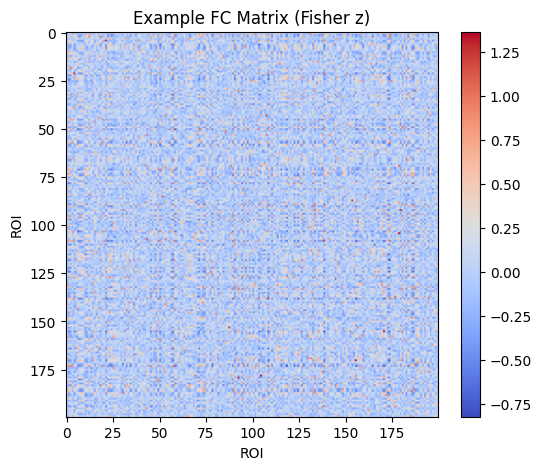

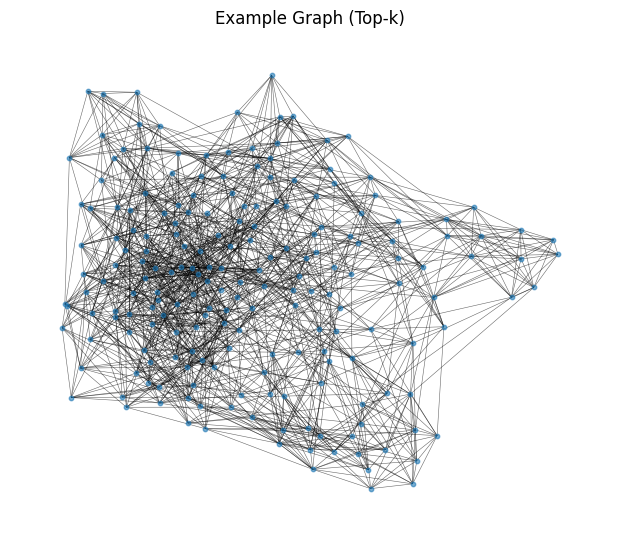

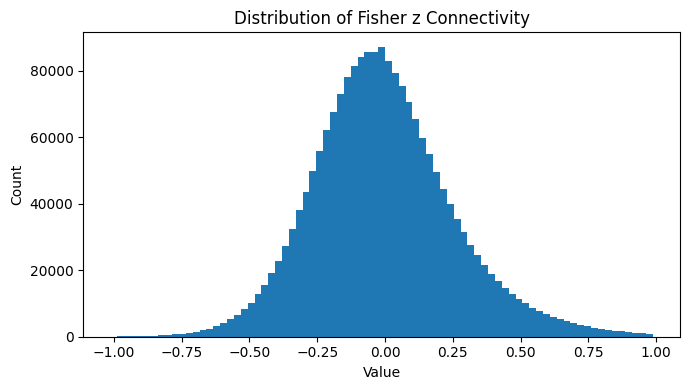

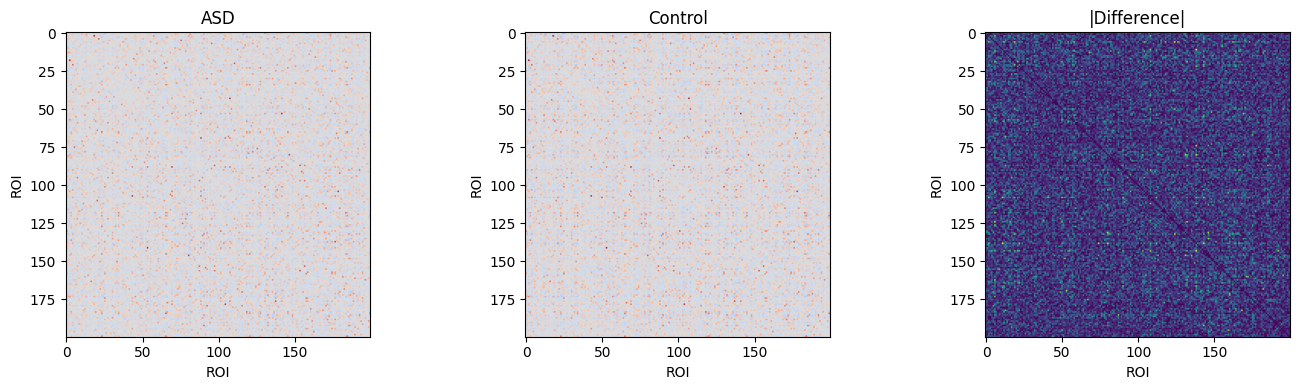

{'example_subject': 'UM_2_0050382',
 'graph_stats': {'num_graphs': 1035,
  'nodes_unique': [200],
  'edges_mean': 1348.6444444444444,
  'edges_std': 58.483204208129806,
  'edges_min': 537,
  'edges_max': 1553}}

In [4]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# Paths
base = Path("data/abide_fmri")
fc_dir = base / "connectivity_matrices"
index_path = base / "connectivity_index.csv"
graph_path = base / "pyg" / "graphs_top10.pt"

# Load metadata
index_df = pd.read_csv(index_path)
index_df = index_df[index_df["DX_GROUP"].isin([1, 2])].copy()
index_df["FILE_ID"] = index_df["FILE_ID"].astype(str)
index_df = index_df[index_df["FILE_ID"].apply(lambda fid: (fc_dir / f"{fid}.npy").exists())]

graphs = torch.load(graph_path, weights_only=False)

# -----------------------------
# 1) Example FC matrix
# -----------------------------
example_fid = index_df.sample(1, random_state=42)["FILE_ID"].iloc[0]

fc = np.load(fc_dir / f"{example_fid}.npy", mmap_mode="r")
fc = np.nan_to_num(fc).astype(np.float32)
np.fill_diagonal(fc, 0)

plt.figure(figsize=(6, 5))
plt.imshow(fc, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Example FC Matrix (Fisher z)")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.show()

# -----------------------------
# 2) Example graph
# -----------------------------
graph_map = {str(getattr(g, "file_id", "")): g for g in graphs}
g = graph_map.get(example_fid, graphs[0])

edge_index = g.edge_index.cpu().numpy()

G = nx.Graph()
G.add_nodes_from(range(g.num_nodes))
G.add_edges_from(edge_index.T.tolist())

plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=10, width=0.4, alpha=0.6)
plt.title("Example Graph (Top-k)")
plt.axis("off")
plt.show()

# -----------------------------
# 3) FC distribution (SAFE + SIMPLE)
#    -> no full concatenation, no streaming stats
# -----------------------------
sample_ids = index_df.sample(n=min(100, len(index_df)), random_state=42)["FILE_ID"]

bins = np.linspace(-1, 1, 80)
hist = np.zeros(len(bins) - 1, dtype=np.float64)

for fid in sample_ids:
    z = np.load(fc_dir / f"{fid}.npy", mmap_mode="r")
    z = np.nan_to_num(z)

    vals = z[np.triu_indices_from(z, k=1)]
    hist += np.histogram(vals, bins=bins)[0]

plt.figure(figsize=(7, 4))
plt.bar(bins[:-1], hist, width=bins[1] - bins[0])
plt.title("Distribution of Fisher z Connectivity")
plt.xlabel("Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Class-level means (SAFE + BALANCED SAMPLING)
# -----------------------------

def mean_fc(ids, max_n=25):
    ids = list(ids)
    ids = ids[:max_n]  # cap per class for stability

    acc = None
    count = 0

    for fid in ids:
        z = np.load(fc_dir / f"{fid}.npy", mmap_mode="r")
        z = np.nan_to_num(z)
        np.fill_diagonal(z, 0)

        if acc is None:
            acc = np.zeros_like(z, dtype=np.float32)

        acc += z.astype(np.float32)
        count += 1

    return acc / max(count, 1)


# balanced sampling from each class (important fix)
asd_pool = index_df[index_df["DX_GROUP"] == 1]["FILE_ID"]
ctl_pool = index_df[index_df["DX_GROUP"] == 2]["FILE_ID"]

asd_ids = asd_pool.sample(n=min(25, len(asd_pool)), random_state=42)
ctl_ids = ctl_pool.sample(n=min(25, len(ctl_pool)), random_state=42)

mean_asd = mean_fc(asd_ids)
mean_ctl = mean_fc(ctl_ids)
diff = np.abs(mean_asd - mean_ctl)

vmax = np.max(np.abs([mean_asd, mean_ctl]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(mean_asd, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("ASD")

axes[1].imshow(mean_ctl, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("Control")

axes[2].imshow(diff, cmap="viridis")
axes[2].set_title("|Difference|")

for ax in axes:
    ax.set_xlabel("ROI")
    ax.set_ylabel("ROI")

plt.tight_layout()
plt.show()

# -----------------------------
# 5) Graph stats
# -----------------------------
node_counts = [g.num_nodes for g in graphs]
edge_counts = [g.edge_index.shape[1] // 2 for g in graphs]

graph_stats = {
    "num_graphs": len(graphs),
    "nodes_unique": sorted(set(node_counts)),
    "edges_mean": float(np.mean(edge_counts)),
    "edges_std": float(np.std(edge_counts)),
    "edges_min": int(np.min(edge_counts)),
    "edges_max": int(np.max(edge_counts)),
}

eda_summary = {
    "example_subject": example_fid,
    "graph_stats": graph_stats,
}

eda_summary

# Model Descriptions

## Training Objective

All models are trained as binary classifiers, but the optimization objective differs by model family.

For matrix-based models (Logistic Regression and MLP), the training objective is binary cross-entropy (BCE). Given a dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$ with labels $y_i \in \{0,1\}$ and predicted probabilities $\hat{y}_i \in (0,1)$, the loss is defined as:
$$
\mathcal{L} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

This objective encourages the model to assign high probability to the correct class and penalizes confident incorrect predictions.

For graph models (GCN and GAT), training uses 2-class logits with cross-entropy loss (implemented as `CrossEntropyLoss`) and softmax probabilities at inference time.

## Functions and Notation

We use the following standard functions to explain each model:

- **Sigmoid function**:
  $$
  \sigma(z) = \frac{1}{1 + e^{-z}}
  $$
  Maps a real-valued input to a probability in $(0,1)$.

- **ReLU (Rectified Linear Unit)**:
  $$
  \text{ReLU}(z) = \max(0, z)
  $$

- **LeakyReLU** (used in GAT attention):
  $$
  \text{LeakyReLU}(z) =
  \begin{cases}
  z & \text{if } z \geq 0 \\
  \alpha z & \text{if } z < 0
  \end{cases}
  $$
  where $\alpha$ is a small constant.

- **tanh (hyperbolic tangent)**:
  $$
  \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}
  $$
  Maps inputs to the range $(-1, 1)$ and is zero-centered.

- **Nonlinear activation $\phi(\cdot)$**:

  Denotes an element-wise nonlinearity. In practice, this is instantiated as ReLU or tanh for MLPs, ReLU for GCN, and ELU for GAT.

- **Indicator function**:
  $$
  \mathbb{I}[\cdot]
  $$
  evaluates to 1 if the condition is true and 0 otherwise.

## Baseline Reference (Majority-Class Accuracy)

As a reference point, we use the majority-class accuracy value from the training split.

In the training split (80/20 stratified), the majority class corresponds to control subjects, yielding a reference accuracy of 51.2%. This value is shown as a comparison baseline in plots.

## Models Trained on the Matrix Representation

Each subject is represented by the upper triangular entries of the Fisher z-transformed connectivity matrix (excluding the diagonal), yielding a feature vector of size:
$$
\frac{200 \cdot 199}{2} = 19{,}900
$$

Features are standardized using z-scoring based on training data statistics.

### Logistic Regression

Logistic regression provides a linear baseline for classification on vectorized functional connectivity features.
This model learns a single global weight for each connection in the connectivity matrix and combines them linearly. Each feature contributes independently to the prediction, making the model easy to interpret but unable to capture interactions between connections.

#### Mathematical Formulation

The model estimates:
$$
P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

and is trained by minimizing binary cross-entropy loss.

#### Forward Pass and Prediction

Given input $\mathbf{x}$:

1. Linear score:
   $$
   z = \mathbf{w}^\top \mathbf{x} + b
   $$

2. Probability:
   $$
   \hat{y} = \sigma(z)
   $$

3. Class prediction:
   $$
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

### Multilayer Perceptron (MLP)

The MLP extends logistic regression by introducing non-linear transformations through hidden layers.
Instead of assigning a single weight per feature, the MLP learns hierarchical combinations of connections. Hidden layers allow the model to capture interactions between multiple edges, enabling more complex decision boundaries at the cost of reduced interpretability.

#### Mathematical Formulation

An $L$-layer MLP computes:
$$
\mathbf{h}^{(l)} = \phi(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)})
$$

with output:
$$
\hat{y} = \sigma(\mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + b^{(L)})
$$

#### Forward Pass and Prediction

Given input $\mathbf{x}$:

1. Initialize:
   $$
   \mathbf{h}^{(0)} = \mathbf{x}
   $$

2. Hidden layers (ReLU or tanh applied element-wise):
   $$
   \mathbf{h}^{(l)} = \phi(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}), \quad l = 1, \dots, L-1
   $$

3. Output logits:
   $$
   z = \mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + b^{(L)}
   $$

4. Probability and prediction:
   $$
   \hat{y} = \sigma(z), \quad
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

## Models Trained on the Graph Representation

Each subject is represented as a graph:
- Nodes: 200 ROIs  
- Edges: top-$k$ strongest connections per node ($k = 10$)  
- Node features: each node is represented by its connectivity profile (200-dimensional)

Node features are normalized independently per node using z-score normalization across the feature dimension.

### Graph Convolutional Network (GCN)

The GCN operates directly on graph-structured functional connectivity data.
The GCN treats the brain as a graph and updates each node by averaging information from its neighbors. This enforces a locality bias: predictions depend on patterns of connectivity within neighborhoods rather than individual edges. The final graph representation summarizes these localized patterns across all nodes.

#### Mathematical Formulation

A GCN layer computes:
$$
\mathbf{H}^{(l+1)} = \phi\left( \tilde{\mathbf{D}}^{-1/2} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-1/2} \mathbf{H}^{(l)} \mathbf{W}^{(l)} \right)
$$

#### Forward Pass and Prediction

Given $\mathbf{H}^{(0)} \in \mathbb{R}^{N \times d}$:

1. First layer (ReLU applied after aggregation):
   $$
   \mathbf{H}^{(1)} = \phi(\tilde{\mathbf{A}}_{\text{norm}} \mathbf{H}^{(0)} \mathbf{W}^{(0)})
   $$

2. Second layer:
   $$
   \mathbf{H}^{(2)} = \phi(\tilde{\mathbf{A}}_{\text{norm}} \mathbf{H}^{(1)} \mathbf{W}^{(1)})
   $$

3. Global mean pooling:
   $$
   \mathbf{h}_{\text{graph}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{h}_i^{(2)}
   $$

4. Classification:
   $$
   \mathbf{p} = \operatorname{softmax}(\mathbf{W}\mathbf{h}_{\text{graph}} + \mathbf{b}), \quad
   \hat{y}_{\text{class}} = \arg\max_c p_c
   $$

### Graph Attention Network (GAT)

The GAT extends GCN by learning attention weights over neighboring nodes.
Instead of treating all neighbors equally, the GAT learns to weight them based on their relevance. This allows the model to focus on the most informative connections for each node, rather than averaging indiscriminately, leading to a more flexible and adaptive notion of neighborhood structure.


#### Mathematical Formulation

Attention coefficients:
$$
\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(\mathbf{a}^\top [\mathbf{W}\mathbf{h}_i \, \| \, \mathbf{W}\mathbf{h}_j]))}{\sum_{k \in \mathcal{N}(i)} \exp(\cdot)}
$$

Node updates:
$$
\mathbf{h}_i' = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij} \mathbf{W}\mathbf{h}_j \right)
$$

#### Forward Pass and Prediction

Given $\{\mathbf{h}_i^{(0)}\}$:

1. First attention layer:
   $$
   \mathbf{h}_i^{(1)} = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij} \mathbf{W}^{(0)} \mathbf{h}_j^{(0)} \right)
   $$

2. Second attention layer:
   $$
   \mathbf{h}_i^{(2)} = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^{(2)} \mathbf{W}^{(1)} \mathbf{h}_j^{(1)} \right)
   $$

3. Global pooling:
   $$
   \mathbf{h}_{\text{graph}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{h}_i^{(2)}
   $$

4. Classification:
   $$
   \mathbf{p} = \operatorname{softmax}(\mathbf{W}\mathbf{h}_{\text{graph}} + \mathbf{b}), \quad
   \hat{y}_{\text{class}} = \arg\max_c p_c
   $$

# Training with Cross-Validation and Hyperparameter Tuning

Hyperparameter tuning uses 5-fold stratified cross-validation on the training set.
For **matrix models** (LogReg, MLP), `GridSearchCV` is used. For **graph models** (GCN, GAT),
a manual grid search loops over all config combinations and selects the best mean CV AUC.

| Model | Grid | Configs | Epochs | Est. time |
|-------|------|---------|--------|-----------|
| LogReg | C ∈ {0.1, 1, 10} | 3 | — | ~3 min |
| MLP | 2 hidden × 3 α | 6 | — | ~15 min |
| GCN | 3 hidden × 2 lr × 2 drop | 12 | 80×5 folds | ~2 hr |
| GAT | 2 hidden × 2 heads × 3 lr | 12 | 80×5 folds | ~3 hr |

The best config per model is retrained on the full training set for final test evaluation.


## Training Details

Neural network models (MLP, GCN, GAT) are trained using the Adam optimizer.

- **MLP**:
  - Maximum iterations: 600  
  - Early stopping enabled (validation fraction = 0.1)

- **GCN and GAT**:
  - Trained for 60 epochs  
  - GCN uses ReLU activations; GAT uses ELU activations  


## Hyperparameter Search

We perform grid search over predefined hyperparameter spaces for each model. All models are evaluated under identical cross-validation settings to ensure comparability of results.

### Logistic Regression

- Regularization type: L1, L2, ElasticNet  
- Solver: `lbfgs` (L2), `saga` (L1, ElasticNet)  
- Regularization strength:
  - L2: $[10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10, 100]$
  - L1: $[10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10]$
  - ElasticNet: $[10^{-3}, 10^{-2}, 10^{-1}, 1, 10]$
- ElasticNet mixing parameter: $\{0.25, 0.5, 0.75\}$
- Class weighting: $\{\text{None}, \text{balanced}\}$
- Maximum iterations: 3000


### Multilayer Perceptron (MLP)

- Hidden layer architectures:
  - $(64)$, $(128)$, $(256)$  
  - $(128, 64)$, $(256, 128)$  
  - $(128, 64, 32)$  
- Activation functions: ReLU, tanh  
- Learning rate: $[10^{-4}, 5 \times 10^{-4}, 10^{-3}]$  
- Batch size: $\{16, 32\}$  
- Additional detail:
  - No dropout (not supported in `sklearn` MLPClassifier)


### Graph Convolutional Network (GCN)

- Hidden dimension: $\{16, 32, 64, 96, 128\}$  
- Dropout: $\{0.2, 0.3, 0.5\}$  
- Learning rate: $\{10^{-3}, 5 \times 10^{-4}\}$  
- Weight decay: $\{0, 10^{-4}\}$  

The GCN hyperparameter space is fully enumerated via grid search over all combinations of the above values. This results in a comprehensive exploration of model capacity and regularization strength under identical training conditions.


### Graph Attention Network (GAT)

Due to the higher computational cost of attention-based message passing, a reduced but structured hyperparameter search space is used for GAT, while preserving comparability with GCN.

- Hidden dimension: $\{16, 32\}$  
- Attention heads (first layer): $\{2, 4\}$  
- Dropout: $\{0.3, 0.5\}$  
- Learning rate: $\{5 \times 10^{-4}, 10^{-3}\}$  
- Weight decay: fixed ($10^{-4}$)

This reduced grid is designed to focus on stable regions identified in the GCN experiments (particularly lower learning rates and stronger regularization), while maintaining variation in model capacity and attention complexity.


## Cross-Validation and Metrics

Cross-validation is used to obtain a more reliable estimate of model performance during hyperparameter selection, particularly given the moderate dataset size. Averaging performance across multiple stratified splits reduces sensitivity to any single train/validation partition and mitigates variance in model selection.

ROC-AUC is used as the primary selection metric. It is computed by plotting the true positive rate against the false positive rate across all possible decision thresholds, and then measuring the area under this curve. Intuitively, it quantifies how well a model ranks positive samples higher than negative samples.

A ROC-AUC of 0.5 corresponds to random guessing, while a value of 1.0 indicates perfect separation between classes. Because it evaluates ranking quality rather than fixed class labels, it is well-suited for model selection during cross-validation, especially when comparing probabilistic classifiers.

During cross-validation, ROC-AUC is computed on each validation fold, and the mean across folds is used to compare hyperparameter configurations.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
 )

# Shared modeling constants (used by matrix + graph pipelines)
RANDOM_SEED = 42
CV_FOLDS = 5
GRAPH_BATCH_SIZE = 32
GRAPH_EPOCHS = 60
GAT_DEFAULT_WEIGHT_DECAY = 1e-4
CLASS_NAMES = ["Control", "ASD"]
TUNING_VERBOSE = False

BASE_DIR = Path("data/abide_fmri")
MAT_DIR = BASE_DIR / "connectivity_matrices"
PYG_DIR = BASE_DIR / "pyg"

# Single CV object reused by all models
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

def load_and_flatten_matrices(file_ids):
    """Load Fisher z-transformed FC matrices and flatten upper triangle."""
    X = []
    for fid in file_ids:
        mat_path = MAT_DIR / f"{fid}.npy"
        if mat_path.exists():
            z = np.load(mat_path)
            z = np.nan_to_num(z).astype(np.float32)
            np.fill_diagonal(z, 0.0)
            features = z[np.triu_indices_from(z, k=1)]  # Extract upper triangle (19,900 dims)
            X.append(features)
    return np.array(X) if X else None

# Get train and test split IDs and labels
train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
test_fids = split_df[split_df["split"] == "test"]["FILE_ID"].values

train_labels = split_df[split_df["split"] == "train"]["DX_GROUP"].values
test_labels = split_df[split_df["split"] == "test"]["DX_GROUP"].values

# Convert labels: 1=ASD -> 1, 2=Control -> 0
y_train = np.array([1 if l == 1 else 0 for l in train_labels])
y_test = np.array([1 if l == 1 else 0 for l in test_labels])

# Load Fisher-transformed matrices and flatten
X_matrix_train = load_and_flatten_matrices(train_fids)
X_matrix_test = load_and_flatten_matrices(test_fids)

# Z-score normalization using training set statistics
scaler = StandardScaler()
X_matrix_train = scaler.fit_transform(X_matrix_train)
X_matrix_test = scaler.transform(X_matrix_test)

print(f"Train shape: {X_matrix_train.shape}, Test shape: {X_matrix_test.shape}")
print(f"Class distribution (train): ASD={np.sum(y_train)}, Control={np.sum(y_train == 0)}")
print(f"Class distribution (test):  ASD={np.sum(y_test)}, Control={np.sum(y_test == 0)}")

In [ ]:
from sklearn.linear_model import LogisticRegression

log("Starting site-holdout baseline training...")
log("  Logistic Regression — 3 configs × 5-fold CV")

# Lean grid: C ∈ {0.1, 1.0, 10.0}, L2/lbfgs — ~3 min
param_grid = [{"C": [0.1, 1.0, 10.0], "penalty": ["l2"], "solver": ["lbfgs"], "class_weight": [None]}]

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=cv,
    n_jobs=2,
    scoring="roc_auc",
    refit=True,
)
grid.fit(X_matrix_train, y_train)

log(f"  LogReg done — best C={grid.best_params_['C']}, CV AUC={grid.best_score_:.4f}")
print(f"Best params: {grid.best_params_}")
print(f"CV ROC-AUC:  {grid.best_score_:.4f}")


In [ ]:
from sklearn.neural_network import MLPClassifier

log("  MLP — 6 configs × 5-fold CV (2 hidden × 3 α)")

# Lean grid: 2 hidden sizes × 3 regularization values = 6 configs — ~15 min
param_grid_mlp = {
    "hidden_layer_sizes": [(64,), (128,)],
    "alpha": [0.0001, 0.001, 0.01],
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(
        max_iter=500,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.1,
    ),
    param_grid=param_grid_mlp,
    cv=cv,
    n_jobs=2,
    scoring="roc_auc",
    refit=True,
)
grid_mlp.fit(X_matrix_train, y_train)

log(f"  MLP done — best {grid_mlp.best_params_}, CV AUC={grid_mlp.best_score_:.4f}")
print(f"Best params: {grid_mlp.best_params_}")
print(f"CV ROC-AUC:  {grid_mlp.best_score_:.4f}")


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

# Reuse in-memory graph splits; fallback to disk if needed
if "train_graphs" not in globals() or "test_graphs" not in globals():
    train_graphs = torch.load(PYG_DIR / "graphs_top10_train.pt", weights_only=False)
    test_graphs = torch.load(PYG_DIR / "graphs_top10_test.pt", weights_only=False)

# Remove edge_attr from older graph files; this pipeline uses unweighted edges.
for g in (train_graphs + test_graphs):
    if hasattr(g, "edge_attr"):
        del g.edge_attr

# Filter to only labeled graphs (exclude any with y=None)
train_graphs = [g for g in train_graphs if hasattr(g, "y") and g.y is not None]
test_graphs = [g for g in test_graphs if hasattr(g, "y") and g.y is not None]

if len(train_graphs) == 0 or len(test_graphs) == 0:
    raise ValueError("Train/test graph lists are empty after filtering labeled graphs.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# Dataset-level sanity checks for the unweighted graph pipeline.
train_example = train_graphs[0]
test_example = test_graphs[0]
print(f"Train graph spec: nodes={train_example.num_nodes}, edges={train_example.edge_index.shape[1]}, unweighted graph used")
print(f"Test graph spec: nodes={test_example.num_nodes}, edges={test_example.edge_index.shape[1]}, unweighted graph used")

in_channels = train_graphs[0].x.shape[1]
num_classes = 2

# Keep graph CV folds aligned with shared CV configuration.
graph_cv_splits = int(cv.n_splits)
print(f"Graph CV folds: {graph_cv_splits}")

def make_loaders(train_data, test_data, batch_size=GRAPH_BATCH_SIZE):
    """Create DataLoaders for graph batching during training/evaluation."""
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

@torch.no_grad()
def predict_labels_and_probs(model, loader):
    """Return y_true, y_prob, y_pred arrays from a graph loader."""
    model.eval()
    ys, probs = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        p = torch.softmax(logits, dim=1)[:, 1]
        y = batch.y.view(-1).long()

        ys.extend(y.cpu().numpy().tolist())
        probs.extend(p.cpu().numpy().tolist())

    ys = np.array(ys)
    probs = np.array(probs)
    preds = (probs >= 0.5).astype(int)
    return ys, probs, preds

@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model on a graph loader; returns accuracy and ROC-AUC."""
    ys, probs, preds = predict_labels_and_probs(model, loader)
    acc = accuracy_score(ys, preds)
    auc = roc_auc_score(ys, probs) if len(np.unique(ys)) > 1 else np.nan
    return {"acc": acc, "auc": auc}

def train_for_epochs(model, train_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train one model for a fixed number of epochs on the provided loader."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = model(batch)
            y = batch.y.view(-1).long()
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return model

def train_one_model(model, train_loader, test_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train on train_loader then return metrics on test_loader."""
    model = train_for_epochs(model, train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
    return evaluate(model, test_loader)

def cross_validate_graph_model(
    model_builder,
    graphs,
    lr,
    weight_decay,
    epochs=GRAPH_EPOCHS,
    batch_size=GRAPH_BATCH_SIZE,
    n_splits=CV_FOLDS,
    random_state=RANDOM_SEED,
    verbose=False,
 ):
    """Run stratified K-fold CV on training graphs and return aggregate metrics."""
    labels = np.array([int(g.y.view(-1).item()) for g in graphs])
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_metrics = []
    for fold_idx, (tr_idx, va_idx) in enumerate(splitter.split(np.zeros(len(graphs)), labels), start=1):
        fold_train = [graphs[i] for i in tr_idx]
        fold_val = [graphs[i] for i in va_idx]

        fold_train_loader = DataLoader(fold_train, batch_size=batch_size, shuffle=True)
        fold_val_loader = DataLoader(fold_val, batch_size=batch_size, shuffle=False)

        model = model_builder()
        model = train_for_epochs(model, fold_train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
        metrics = evaluate(model, fold_val_loader)
        fold_metrics.append(metrics)
        if verbose:
            print(f"  Fold {fold_idx}/{n_splits} - acc: {metrics['acc']:.4f}, auc: {metrics['auc']:.4f}")

    accs = np.array([m["acc"] for m in fold_metrics], dtype=float)
    aucs = np.array([m["auc"] for m in fold_metrics], dtype=float)

    return {
        "cv_acc_mean": float(np.nanmean(accs)),
        "cv_acc_std": float(np.nanstd(accs)),
        "cv_auc_mean": float(np.nanmean(aucs)),
        "cv_auc_std": float(np.nanstd(aucs)),
        "fold_metrics": fold_metrics,
    }

class GCNNet(nn.Module):
    """Graph Convolutional Network: 2-layer GCN with dropout and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

class GATNet(nn.Module):
    """Graph Attention Network: 2-layer GAT with multi-head attention and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, heads=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_dim, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=dropout)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

# Keep holdout loaders for final test evaluation.
train_loader, test_loader = make_loaders(train_graphs, test_graphs, batch_size=GRAPH_BATCH_SIZE)
print("Graph setup ready: CV utilities + holdout loaders + model classes defined.")

Device: cpu
Train graphs: 828 | Test graphs: 207
Train graph spec: nodes=200, edges=2654, unweighted graph used
Test graph spec: nodes=200, edges=2732, unweighted graph used
Graph CV folds: 5
Graph setup ready: CV utilities + holdout loaders + model classes defined.


In [ ]:
import itertools

# Lean GCN grid: 3 hidden × 2 lr × 2 dropout = 12 configs × 5 folds × 80 epochs
# RUNTIME: ~2 hours
GCN_EPOCHS = 80

_gcn_grid = list(itertools.product(
    [32, 64, 128],    # hidden_dim
    [0.0001, 0.001],  # lr
    [0.2, 0.4],       # dropout
))

log(f"  GCN grid search — {len(_gcn_grid)} configs × 5 folds × {GCN_EPOCHS} epochs")

gcn_results = []
try:
    for hidden_dim, lr, dropout in _gcn_grid:
        _hd, _dr = hidden_dim, dropout
        metrics = cross_validate_graph_model(
            model_builder=lambda hd=_hd, dr=_dr: GCNNet(
                in_channels=in_channels, hidden_dim=hd, dropout=dr),
            graphs=train_graphs,
            lr=lr,
            weight_decay=1e-4,
            epochs=GCN_EPOCHS,
            batch_size=GRAPH_BATCH_SIZE,
            n_splits=graph_cv_splits,
            random_state=RANDOM_SEED,
            verbose=False,
        )
        row = {
            "hidden_dim": hidden_dim, "dropout": dropout,
            "lr": lr, "weight_decay": 1e-4,
            "cv_acc_mean": metrics["cv_acc_mean"], "cv_acc_std": metrics["cv_acc_std"],
            "cv_auc_mean": metrics["cv_auc_mean"], "cv_auc_std": metrics["cv_auc_std"],
        }
        gcn_results.append(row)
        log(f"    GCN h={hidden_dim} lr={lr} drop={dropout} → CV AUC={metrics['cv_auc_mean']:.4f}")
except Exception as e:
    log(f"ERROR in GCN grid search: {e}")
    import traceback; traceback.print_exc()
    if not gcn_results:
        raise

gcn_results = sorted(
    gcn_results,
    key=lambda x: (float("nan") if x["cv_auc_mean"] != x["cv_auc_mean"] else x["cv_auc_mean"], x["cv_acc_mean"]),
    reverse=True,
)
log(f"  GCN best: h={gcn_results[0]['hidden_dim']} lr={gcn_results[0]['lr']} "
    f"drop={gcn_results[0]['dropout']} → CV AUC={gcn_results[0]['cv_auc_mean']:.4f}")
print(f"GCN best config: {gcn_results[0]}")


In [ ]:
import itertools

# Lean GAT grid: 2 hidden × 2 heads × 3 lr × 1 dropout = 12 configs × 5 folds × 80 epochs
# RUNTIME: ~3 hours
GAT_EPOCHS = 80

_gat_grid = list(itertools.product(
    [32, 64],                # hidden_dim
    [4, 8],                  # heads
    [0.0001, 0.001, 0.01],   # lr
    [0.3],                   # dropout
))

log(f"  GAT grid search — {len(_gat_grid)} configs × 5 folds × {GAT_EPOCHS} epochs")

gat_results = []
try:
    for hidden_dim, heads, lr, dropout in _gat_grid:
        _hd, _h, _dr = hidden_dim, heads, dropout
        metrics = cross_validate_graph_model(
            model_builder=lambda hd=_hd, h=_h, dr=_dr: GATNet(
                in_channels=in_channels, hidden_dim=hd, heads=h, dropout=dr),
            graphs=train_graphs,
            lr=lr,
            weight_decay=GAT_DEFAULT_WEIGHT_DECAY,
            epochs=GAT_EPOCHS,
            batch_size=GRAPH_BATCH_SIZE,
            n_splits=graph_cv_splits,
            random_state=RANDOM_SEED,
            verbose=False,
        )
        row = {
            "hidden_dim": hidden_dim, "heads": heads, "dropout": dropout,
            "lr": lr, "weight_decay": GAT_DEFAULT_WEIGHT_DECAY,
            "cv_acc_mean": metrics["cv_acc_mean"], "cv_acc_std": metrics["cv_acc_std"],
            "cv_auc_mean": metrics["cv_auc_mean"], "cv_auc_std": metrics["cv_auc_std"],
        }
        gat_results.append(row)
        log(f"    GAT h={hidden_dim} heads={heads} lr={lr} → CV AUC={metrics['cv_auc_mean']:.4f}")
except Exception as e:
    log(f"ERROR in GAT grid search: {e}")
    import traceback; traceback.print_exc()
    if not gat_results:
        raise

gat_results = sorted(
    gat_results,
    key=lambda x: (float("nan") if x["cv_auc_mean"] != x["cv_auc_mean"] else x["cv_auc_mean"], x["cv_acc_mean"]),
    reverse=True,
)
log(f"  GAT best: h={gat_results[0]['hidden_dim']} heads={gat_results[0]['heads']} "
    f"lr={gat_results[0]['lr']} → CV AUC={gat_results[0]['cv_auc_mean']:.4f}")
print(f"GAT best config: {gat_results[0]}")


# Evaluation on the Test Set

After tuning model hyperparameters using k-fold cross-validation, we retrain them on the full training set before evaluating them with the held out test set to evaluate model performance on unseen data. However, since the test/train split was not site-stratified, model performance on the test-set only generalizes to new subjects under matched multi-site conditions rather than entirely novel sites. 

In [13]:
log("Starting final evaluation on test set...")
# Matrix-model evaluations (already tuned via GridSearchCV)
y_pred_logreg = grid.predict(X_matrix_test)
y_pred_proba_logreg = grid.predict_proba(X_matrix_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

y_pred_mlp = grid_mlp.predict(X_matrix_test)
y_pred_proba_mlp = grid_mlp.predict_proba(X_matrix_test)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

def evaluate_graph_model_on_test(model_builder, cfg, epochs=GRAPH_EPOCHS):
    """Train on graph train split once, then evaluate on graph test split."""
    model = model_builder()
    model = train_for_epochs(
        model,
        train_loader,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        epochs=epochs,
    )
    y_true, y_prob, y_pred = predict_labels_and_probs(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    cm = confusion_matrix(y_true, y_pred)
    return model, acc, auc, cm, y_true, y_prob, y_pred

def print_eval_line(model_name, acc, auc):
    print(f"{model_name}: Accuracy={acc:.4f} | ROC-AUC={auc:.4f}")

# Graph-model evaluations (best config selected by CV)
best_gcn = gcn_results[0]
gcn_model, acc_gcn, auc_gcn, cm_gcn, y_test_gcn, y_pred_gcn_probs, y_pred_gcn = evaluate_graph_model_on_test(
    model_builder=lambda hd=int(best_gcn["hidden_dim"]), dr=float(best_gcn["dropout"]): GCNNet(
        in_channels=in_channels, hidden_dim=hd, dropout=dr),
    cfg=best_gcn,
    epochs=GCN_EPOCHS,
)

best_gat = gat_results[0]
gat_model, acc_gat, auc_gat, cm_gat, y_test_gat, y_pred_gat_probs, y_pred_gat = evaluate_graph_model_on_test(
    model_builder=lambda hd=int(best_gat["hidden_dim"]), h=int(best_gat["heads"]), dr=float(best_gat["dropout"]): GATNet(
        in_channels=in_channels, hidden_dim=hd, heads=h, dropout=dr),
    cfg=best_gat,
    epochs=GAT_EPOCHS,
)

# Concise summary for all models
print_eval_line("Logistic Regression", acc_logreg, auc_logreg)
print_eval_line("MLP", acc_mlp, auc_mlp)
print_eval_line("GCN", acc_gcn, auc_gcn)
print_eval_line("GAT", acc_gat, auc_gat)

# Keep table artifact for downstream comparison plots
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP", "GCN", "GAT"],
    "Accuracy": [acc_logreg, acc_mlp, acc_gcn, acc_gat],
    "ROC-AUC": [auc_logreg, auc_mlp, auc_gcn, auc_gat],
})
log("Baseline training complete")
save_checkpoint("baseline_results", {
    "logreg":  {"best_params": grid.best_params_,     "cv_auc": grid.best_score_,     "test_acc": acc_logreg, "test_auc": auc_logreg},
    "mlp":     {"best_params": grid_mlp.best_params_, "cv_auc": grid_mlp.best_score_, "test_acc": acc_mlp,    "test_auc": auc_mlp},
    "gcn":     {"best_config": gcn_results[0],        "test_acc": acc_gcn,            "test_auc": auc_gcn},
    "gat":     {"best_config": gat_results[0],        "test_acc": acc_gat,            "test_auc": auc_gat},
    "results_df": results_df,
})


Logistic Regression: Accuracy=0.7222 | ROC-AUC=0.8006
MLP: Accuracy=0.6728 | ROC-AUC=0.7679
GCN: Accuracy=0.6481 | ROC-AUC=0.7026
GAT: Accuracy=0.6914 | ROC-AUC=0.7220


In [14]:
# Save all model artifacts: best hyperparameters, fitted sklearn estimators, and graph model weights if available.

import json
from pathlib import Path
import joblib
import torch

out = Path("data/abide_fmri/model_artifacts")
out.mkdir(parents=True, exist_ok=True)

# Save best hyperparameters for all models
with open(out / "logreg_best_params.json", "w") as f:
    json.dump(grid.best_params_, f, indent=2)
with open(out / "mlp_best_params.json", "w") as f:
    json.dump(grid_mlp.best_params_, f, indent=2)
with open(out / "gcn_best_params.json", "w") as f:
    json.dump(gcn_results[0], f, indent=2)
with open(out / "gat_best_params.json", "w") as f:
    json.dump(gat_results[0], f, indent=2)

# Save fitted sklearn estimators
joblib.dump(grid.best_estimator_, out / "logreg_best_model.joblib")
joblib.dump(grid_mlp.best_estimator_, out / "mlp_best_model.joblib")

# Save fitted graph model weights if available
saved_graph_models = []
if "gcn_model" in globals() and gcn_model is not None:
    torch.save(gcn_model.state_dict(), out / "gcn_best_state.pt")
    saved_graph_models.append("GCN")

if "gat_model" in globals() and gat_model is not None:
    torch.save(gat_model.state_dict(), out / "gat_best_state.pt")
    saved_graph_models.append("GAT")

print(f"Saved model artifacts to {out}")
if saved_graph_models:
    print("Saved graph model weights:", ", ".join(saved_graph_models))
else:
    print("Graph model objects not found; saved graph hyperparameters only.")

Saved model artifacts to data/abide_fmri/model_artifacts
Saved graph model weights: GCN, GAT


In [22]:
# ─── Evaluation entry point — loads everything from disk ────────────────────
# Requires ONLY: cell 0 (log/save_checkpoint helpers)
# Skip: cells 10, 17, 18, 19, 21, 22, 24, 25
# Exports to kernel: logreg_model, mlp_model, gcn_model, gat_model,
#   X_matrix_train, X_matrix_test, y_train, y_test, train_loader, test_loader,
#   split_df, in_channels, device, results_df, summary_df, CLASS_NAMES,
#   acc/auc/cm for all 4 models, best_gcn, best_gat
# ────────────────────────────────────────────────────────────────────────────
import json, joblib, numpy as np, pandas as pd, torch
from pathlib import Path
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch_geometric.loader import DataLoader

# Graceful fallback if cell 0 was skipped
if "log" not in dir():
    from datetime import datetime as _dt
    def log(msg): print(f"[{_dt.now().strftime('%H:%M:%S')}] {msg}", flush=True)
if "save_checkpoint" not in dir():
    def save_checkpoint(*a, **kw): pass

log("Loading evaluation artifacts from disk...")

ARTIFACTS_DIR    = Path("data/abide_fmri/model_artifacts")
MAT_DIR          = Path("data/abide_fmri/connectivity_matrices")
PYG_DIR          = Path("data/abide_fmri/pyg")
SPLIT_CSV        = Path("data/abide_fmri/subject_split_site_holdout.csv")
CLASS_NAMES      = ["Control", "ASD"]
RANDOM_SEED      = 42
GRAPH_BATCH_SIZE = 32

# ── Verify required files ────────────────────────────────────────────────────
_required = [
    ARTIFACTS_DIR / "logreg_best_model.joblib",
    ARTIFACTS_DIR / "mlp_best_model.joblib",
    ARTIFACTS_DIR / "gcn_best_params.json",
    ARTIFACTS_DIR / "gat_best_params.json",
    ARTIFACTS_DIR / "gcn_best_state.pt",
    ARTIFACTS_DIR / "gat_best_state.pt",
    PYG_DIR / "graphs_top10_test.pt",
    SPLIT_CSV,
]
_missing = [str(p) for p in _required if not p.exists()]
if _missing:
    raise FileNotFoundError("Missing artifact files:\n  " + "\n  ".join(_missing))
log("  All artifact files present.")

# ── Split manifest ────────────────────────────────────────────────────────────
split_df = pd.read_csv(SPLIT_CSV)
split_df["FILE_ID"] = split_df["FILE_ID"].astype(str)
_train_fids    = split_df[split_df["split"] == "train"]["FILE_ID"].values
_test_fids     = split_df[split_df["split"] == "test"]["FILE_ID"].values
_train_labels  = split_df[split_df["split"] == "train"]["DX_GROUP"].values
_test_labels   = split_df[split_df["split"] == "test"]["DX_GROUP"].values
y_train = np.array([1 if l == 1 else 0 for l in _train_labels])
y_test  = np.array([1 if l == 1 else 0 for l in _test_labels])

# ── FC matrices ───────────────────────────────────────────────────────────────
def _load_flatten(file_ids, mat_dir):
    X = []
    for fid in file_ids:
        p = mat_dir / f"{fid}.npy"
        if not p.exists(): continue
        z = np.nan_to_num(np.load(p)).astype(np.float32)
        np.fill_diagonal(z, 0.0)
        X.append(z[np.triu_indices_from(z, k=1)])
    return np.array(X) if X else None

log("  Loading FC matrices...")
_scaler = StandardScaler()
X_matrix_train = _scaler.fit_transform(_load_flatten(_train_fids, MAT_DIR))
X_matrix_test  = _scaler.transform(_load_flatten(_test_fids, MAT_DIR))

# ── Graph data ────────────────────────────────────────────────────────────────
in_channels = 200
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_test_gs  = [g for g in torch.load(PYG_DIR / "graphs_top10_test.pt",  weights_only=False)
             if hasattr(g, "y") and g.y is not None]
test_loader = DataLoader(_test_gs, batch_size=GRAPH_BATCH_SIZE, shuffle=False)

if "train_graphs" not in globals():
    train_graphs = [g for g in torch.load(PYG_DIR / "graphs_top10_train.pt", weights_only=False)
                    if hasattr(g, "y") and g.y is not None]
if "train_loader" not in globals():
    train_loader = DataLoader(train_graphs, batch_size=GRAPH_BATCH_SIZE, shuffle=True)

log(f"  Data ready — train {len(train_graphs)} graphs / {len(_train_fids)} matrix subjects, "
    f"test {len(_test_gs)} / {len(_test_fids)}")

# ── Model class definitions (used if cell 20 hasn't run) ─────────────────────
if "GCNNet" not in globals():
    import torch.nn as nn, torch.nn.functional as F
    from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
    _nc = 2  # num_classes

    class GCNNet(nn.Module):
        def __init__(self, in_channels, hidden_dim=32, dropout=0.5):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.dropout = dropout
            self.classifier = nn.Linear(hidden_dim, _nc)
        def forward(self, data):
            x, ei, b = data.x, data.edge_index, data.batch
            x = F.dropout(F.relu(self.conv1(x, ei)), p=self.dropout, training=self.training)
            x = F.relu(self.conv2(x, ei))
            x = F.dropout(global_mean_pool(x, b), p=self.dropout, training=self.training)
            return self.classifier(x)

    class GATNet(nn.Module):
        def __init__(self, in_channels, hidden_dim=32, heads=2, dropout=0.5):
            super().__init__()
            self.conv1 = GATConv(in_channels, hidden_dim, heads=heads, dropout=dropout)
            self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=dropout)
            self.dropout = dropout
            self.classifier = nn.Linear(hidden_dim, _nc)
        def forward(self, data):
            x, ei, b = data.x, data.edge_index, data.batch
            x = F.dropout(F.elu(self.conv1(x, ei)), p=self.dropout, training=self.training)
            x = F.elu(self.conv2(x, ei))
            x = F.dropout(global_mean_pool(x, b), p=self.dropout, training=self.training)
            return self.classifier(x)

if "predict_labels_and_probs" not in globals():
    import torch.nn.functional as F
    @torch.no_grad()
    def predict_labels_and_probs(model, loader):
        model.eval(); ys, probs = [], []
        for batch in loader:
            batch = batch.to(device)
            p = torch.softmax(model(batch), dim=1)[:, 1]
            ys.extend(batch.y.view(-1).cpu().numpy().tolist())
            probs.extend(p.cpu().numpy().tolist())
        ys = np.array(ys); probs = np.array(probs)
        return ys, probs, (probs >= 0.5).astype(int)

# ── Load sklearn models ───────────────────────────────────────────────────────
logreg_model = joblib.load(ARTIFACTS_DIR / "logreg_best_model.joblib")
mlp_model    = joblib.load(ARTIFACTS_DIR / "mlp_best_model.joblib")
best_gcn     = json.loads((ARTIFACTS_DIR / "gcn_best_params.json").read_text())
best_gat     = json.loads((ARTIFACTS_DIR / "gat_best_params.json").read_text())

# ── Load graph models ─────────────────────────────────────────────────────────
gcn_model = GCNNet(in_channels=in_channels,
                   hidden_dim=int(best_gcn["hidden_dim"]),
                   dropout=float(best_gcn["dropout"])).to(device)
gcn_model.load_state_dict(torch.load(ARTIFACTS_DIR / "gcn_best_state.pt", map_location=device))
gcn_model.eval()

gat_model = GATNet(in_channels=in_channels,
                   hidden_dim=int(best_gat["hidden_dim"]),
                   heads=int(best_gat["heads"]),
                   dropout=float(best_gat["dropout"])).to(device)
gat_model.load_state_dict(torch.load(ARTIFACTS_DIR / "gat_best_state.pt", map_location=device))
gat_model.eval()

# ── Evaluate all models ────────────────────────────────────────────────────────
log("  Evaluating all models on test set...")

y_pred_logreg       = logreg_model.predict(X_matrix_test)
y_pred_proba_logreg = logreg_model.predict_proba(X_matrix_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
cm_logreg  = confusion_matrix(y_test, y_pred_logreg)

y_pred_mlp       = mlp_model.predict(X_matrix_test)
y_pred_proba_mlp = mlp_model.predict_proba(X_matrix_test)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
cm_mlp  = confusion_matrix(y_test, y_pred_mlp)

y_test_gcn, y_pred_gcn_probs, y_pred_gcn = predict_labels_and_probs(gcn_model, test_loader)
acc_gcn = accuracy_score(y_test_gcn, y_pred_gcn)
auc_gcn = roc_auc_score(y_test_gcn, y_pred_gcn_probs) if len(np.unique(y_test_gcn)) > 1 else float("nan")
cm_gcn  = confusion_matrix(y_test_gcn, y_pred_gcn)

y_test_gat, y_pred_gat_probs, y_pred_gat = predict_labels_and_probs(gat_model, test_loader)
acc_gat = accuracy_score(y_test_gat, y_pred_gat)
auc_gat = roc_auc_score(y_test_gat, y_pred_gat_probs) if len(np.unique(y_test_gat)) > 1 else float("nan")
cm_gat  = confusion_matrix(y_test_gat, y_pred_gat)

# ── Results tables ────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "Model":    ["Logistic Regression", "MLP", "GCN", "GAT"],
    "Accuracy": [acc_logreg, acc_mlp, acc_gcn, acc_gat],
    "ROC-AUC":  [auc_logreg, auc_mlp, auc_gcn, auc_gat],
})
summary_rows = [
    ["Logistic Regression", {"C": logreg_model.C, "penalty": logreg_model.penalty},
     acc_logreg, auc_logreg, cm_logreg.tolist()],
    ["MLP", {"hidden_layer_sizes": list(mlp_model.hidden_layer_sizes), "alpha": mlp_model.alpha},
     acc_mlp, auc_mlp, cm_mlp.tolist()],
    ["GCN", {k: best_gcn[k] for k in ("hidden_dim","dropout","lr","weight_decay")},
     acc_gcn, auc_gcn, cm_gcn.tolist()],
    ["GAT", {k: best_gat[k] for k in ("hidden_dim","heads","dropout","lr","weight_decay")},
     acc_gat, auc_gat, cm_gat.tolist()],
]
summary_df = pd.DataFrame(summary_rows,
    columns=["Model","Best Hyperparameters","Test Accuracy","Test ROC-AUC","Confusion Matrix"]
).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)

log("  Done.")
print("\n=== Compact Results Table ===")
print(results_df.sort_values("ROC-AUC", ascending=False).to_string(index=False))
print()
for _, row in summary_df.iterrows():
    print(f"{row['Model']:25s}  Acc={row['Test Accuracy']:.4f}  AUC={row['Test ROC-AUC']:.4f}"
          f"  params={row['Best Hyperparameters']}")


[00:54:40] Loading evaluation artifacts from disk...
[00:54:40]   All artifact files present.
[00:54:40]   Loading FC matrices...
[00:54:41]   Data ready — train 873 graphs / 873 matrix subjects, test 162 / 162
[00:54:42]   Evaluating all models on test set...
[00:54:42]   Done.

=== Compact Results Table ===
              Model  Accuracy  ROC-AUC
Logistic Regression  0.722222 0.800640
                MLP  0.728395 0.775415
                GCN  0.691358 0.771529
                GAT  0.660494 0.723518

Logistic Regression        Acc=0.7222  AUC=0.8006  params={'C': 1.0, 'penalty': 'l2'}
MLP                        Acc=0.7284  AUC=0.7754  params={'hidden_layer_sizes': [64], 'alpha': 0.01}
GCN                        Acc=0.6914  AUC=0.7715  params={'hidden_dim': 128, 'dropout': 0.4, 'lr': 0.0001, 'weight_decay': 0.0001}
GAT                        Acc=0.6605  AUC=0.7235  params={'hidden_dim': 32, 'heads': 8, 'dropout': 0.3, 'lr': 0.0001, 'weight_decay': 0.0001}


## Model Architectures + Best Tuning Results (Per Model)

The following tuned models were retrained and evaluated on their accuracy and ROC-AUC scores. 

### Logistic Regression
Input: upper-triangle functional connectivity (19,900 features)  
Model: linear classifier → sigmoid  

Best hyperparameters:
- Penalty: L2
- Solver: lbfgs
- C: 1.0
- Class weight: None

Test performance:
- Accuracy: 0.7222
- ROC-AUC: 0.8006

### MLP
Input: upper-triangle functional connectivity (19,900 features)  
Model: Dense(64, ReLU) → Dense(1, Sigmoid)

Best hyperparameters:
- Hidden layers: [64]
- L2 alpha: 0.01

Test performance:
- Accuracy: 0.6728 
- ROC-AUC: 0.7679


### GCN
Input: graph (200 ROIs)  
Node features: 200-dim connectivity profile  
Edges: top-k (k=10), unweighted  

Model:
GCNConv(200→128) + ReLU + Dropout(0.4)
GCNConv(128→128) + ReLU
Global mean pooling → Dropout(0.4)
Linear(128→2) → Softmax

Best hyperparameters:
- Hidden dimension: 128
- Dropout: 0.4
- Learning rate: 0.0001
- Weight decay: 0.0001

Test performance:
- Accuracy: 0.6481
- ROC-AUC: 0.7026


### GAT
Input: graph (200 ROIs)  
Node features: 200-dim connectivity profile  
Edges: top-k (k=10), unweighted  

Model:
GATConv(200→32, heads=8) + ELU + Dropout(0.3)
GATConv(256→32, heads=1) + ELU
Global mean pooling → Dropout(0.3)
Linear(32→2) → Softmax

Best hyperparameters:
- Hidden dimension: 32
- Attention heads: 8
- Dropout: 0.3
- Learning rate: 0.0001
- Weight decay: 0.0001

Test performance:
- Accuracy: 0.6914
- ROC-AUC: 0.7220


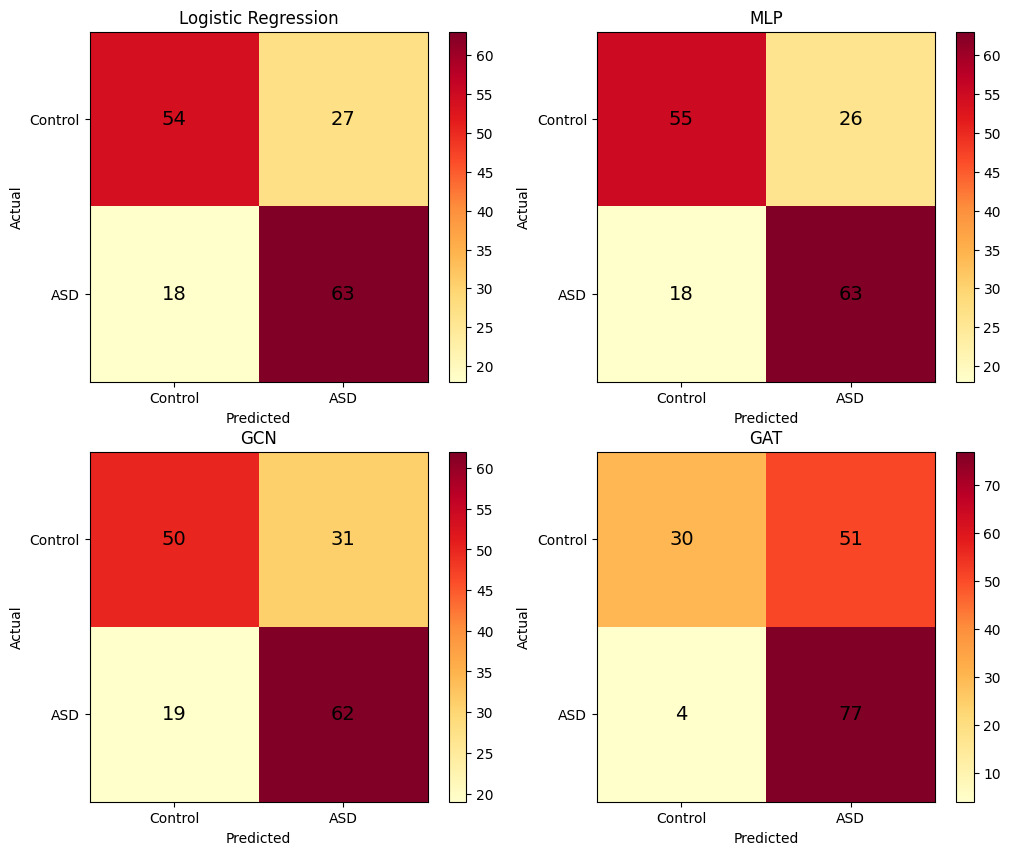

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = ["Logistic Regression", "MLP", "GCN", "GAT"]
cms = [cm_logreg, cm_mlp, cm_gcn, cm_gat]
axes = axes.flatten()

for model_name, cm, ax in zip(models, cms, axes):
    im = ax.imshow(cm, cmap="YlOrRd", aspect="auto")
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)
    plt.colorbar(im, ax=ax)

plt.show()

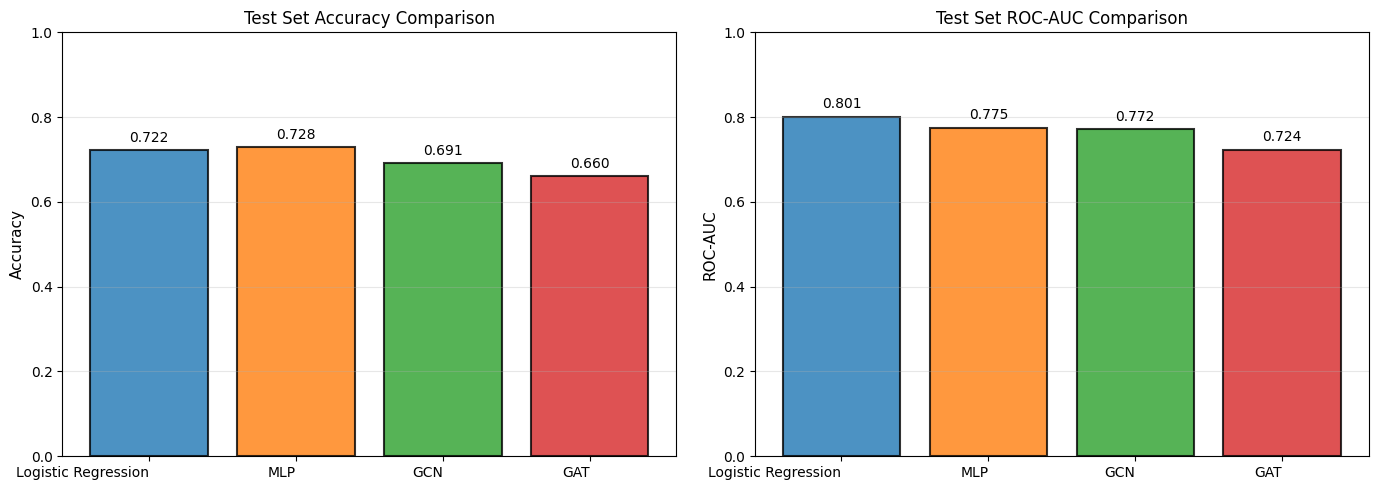

Best Accuracy: MLP (0.7284)
Best ROC-AUC:  Logistic Regression (0.8006)


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
x_pos = np.arange(len(results_df))

ax1.bar(x_pos, results_df["Accuracy"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_title("Test Set Accuracy Comparison", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df["Model"], ha="right")
ax1.set_ylim([0, 1])
ax1.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["Accuracy"]):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha="center")

ax2.bar(x_pos, results_df["ROC-AUC"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax2.set_ylabel("ROC-AUC", fontsize=11)
ax2.set_title("Test Set ROC-AUC Comparison", fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df["Model"], ha="right")
ax2.set_ylim([0, 1])
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["ROC-AUC"]):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

# Summary
best_acc_idx = results_df["Accuracy"].idxmax()
best_auc_idx = results_df["ROC-AUC"].idxmax()
print(f"Best Accuracy: {results_df.loc[best_acc_idx, 'Model']} ({results_df.loc[best_acc_idx, 'Accuracy']:.4f})")
print(f"Best ROC-AUC:  {results_df.loc[best_auc_idx, 'Model']} ({results_df.loc[best_auc_idx, 'ROC-AUC']:.4f})")

---
# Part 2: FC Distribution & Artifact Analysis

Before interpreting model performance, we examine whether site-level signal dominates the diagnostic signal in the FC matrices. If site differences are larger than ASD/control differences, models may exploit scanner artefacts rather than neural signal.

Three checks:
1. KS test: ASD vs Control FC distributions vs train-site vs test-site distributions
2. Per-subject mean FC by site and diagnosis — box plots
3. Per-subject mean ablation: subtract the global FC mean per subject, then re-run LogReg


[00:54:43] Starting artifact distribution analysis...
=== KS Tests ===
ASD vs Control  (train sites): stat=0.0067, p=5.892e-03
ASD vs Control  (test  sites): stat=0.0187,  p=4.089e-04
Train vs Test sites (pooled):  stat=0.0193,     p=1.203e-13

⚠ Site effect > diagnosis effect — scanner artefacts may dominate the signal.


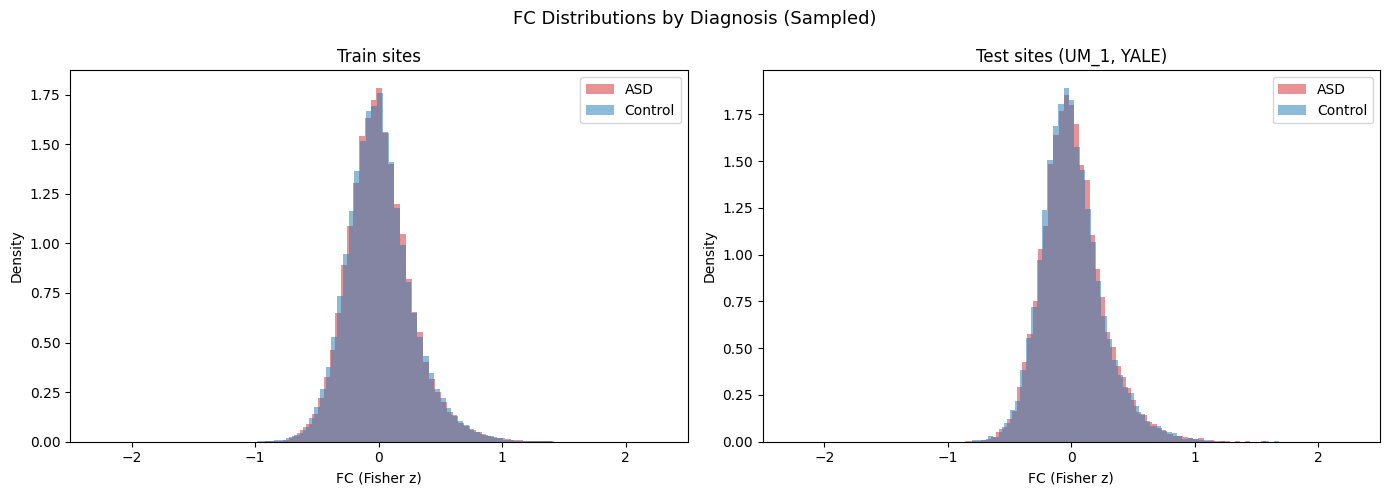

In [25]:
log("Starting artifact distribution analysis...")
# Part 2a: FC value distributions by (split, diagnosis) + KS tests
# RUNTIME: ~2 minutes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

_base = Path("data/abide_fmri")
_mat_dir = _base / "connectivity_matrices"
_split_site = pd.read_csv(_base / "subject_split_site_holdout.csv")
_split_site["FILE_ID"] = _split_site["FILE_ID"].astype(str)

np.random.seed(42)
N_FC_VALS = 300  # sampled upper-triangle values per subject

groups = {}
for _, row in _split_site.iterrows():
    fid = str(row["FILE_ID"])
    mat_path = _mat_dir / f"{fid}.npy"
    if not mat_path.exists():
        continue
    dx  = "ASD" if row["DX_GROUP"] == 1 else "Control"
    key = (row["split"], dx)
    if key not in groups:
        groups[key] = []
    mat = np.load(mat_path, mmap_mode="r")
    tri = mat[np.triu_indices(mat.shape[0], k=1)]
    idx = np.random.choice(len(tri), min(N_FC_VALS, len(tri)), replace=False)
    groups[key].extend(tri[idx].tolist())

train_asd  = np.array(groups.get(("train","ASD"),  []))
train_ctrl = np.array(groups.get(("train","Control"), []))
test_asd   = np.array(groups.get(("test","ASD"),   []))
test_ctrl  = np.array(groups.get(("test","Control"),  []))

ks_dx_train = stats.ks_2samp(train_asd, train_ctrl)
ks_dx_test  = stats.ks_2samp(test_asd,  test_ctrl)
ks_site     = stats.ks_2samp(
    np.concatenate([train_asd, train_ctrl]),
    np.concatenate([test_asd,  test_ctrl]))

print("=== KS Tests ===")
print(f"ASD vs Control  (train sites): stat={ks_dx_train.statistic:.4f}, p={ks_dx_train.pvalue:.3e}")
print(f"ASD vs Control  (test  sites): stat={ks_dx_test.statistic:.4f},  p={ks_dx_test.pvalue:.3e}")
print(f"Train vs Test sites (pooled):  stat={ks_site.statistic:.4f},     p={ks_site.pvalue:.3e}")
print()
if ks_site.statistic > max(ks_dx_train.statistic, ks_dx_test.statistic):
    print("\u26a0 Site effect > diagnosis effect — scanner artefacts may dominate the signal.")
else:
    print("\u2713 Diagnosis effect >= site effect — signal appears to be biologically driven.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (role, title) in zip(axes, [("train","Train sites"),("test","Test sites (UM_1, YALE)")]):
    a = np.array(groups.get((role,"ASD"),  []))
    c = np.array(groups.get((role,"Control"), []))
    if len(a): ax.hist(a, bins=60, alpha=0.5, label="ASD",     density=True, color="#d62728")
    if len(c): ax.hist(c, bins=60, alpha=0.5, label="Control", density=True, color="#1f77b4")
    ax.set_xlabel("FC (Fisher z)"); ax.set_ylabel("Density")
    ax.set_title(title); ax.legend(); ax.set_xlim(-2.5, 2.5)
plt.suptitle("FC Distributions by Diagnosis (Sampled)", fontsize=13)
plt.tight_layout()
plt.show()


T-test ASD vs Control mean FC:      t=2.955,   p=3.2022e-03
T-test train sites vs test sites:   t=-4.216, p=2.7022e-05


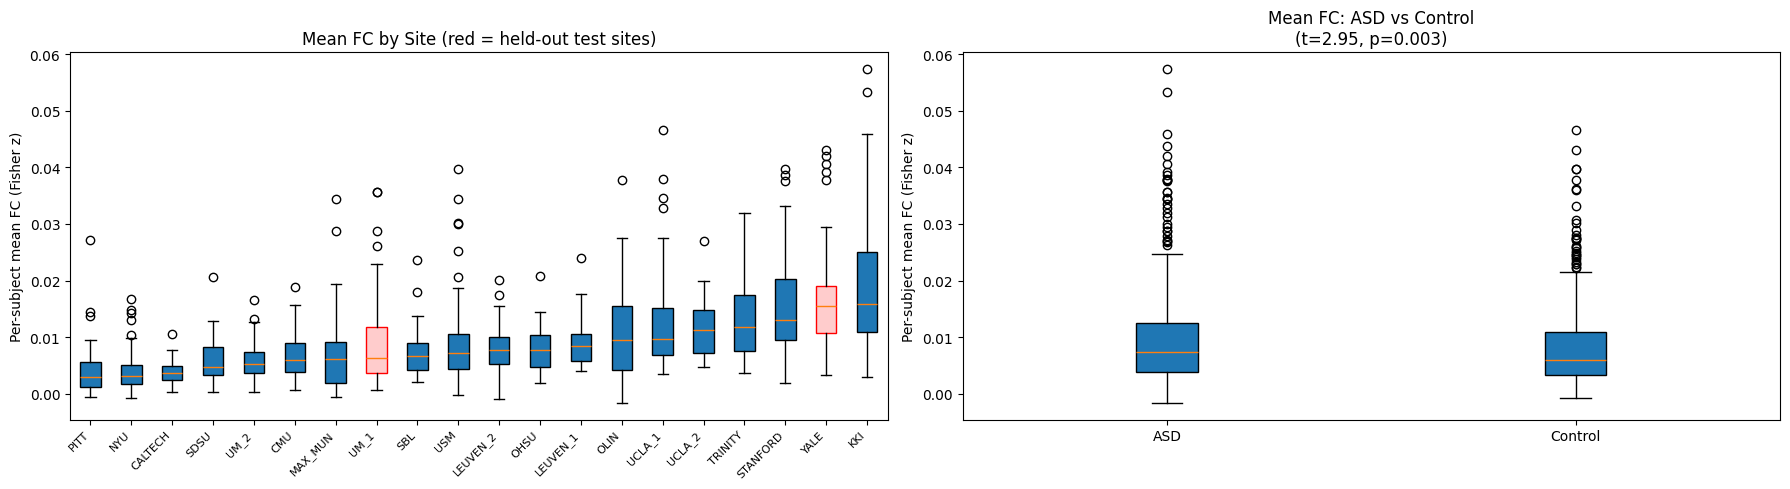


If site variance >> diagnosis variance, scanner artefacts likely dominate.


In [26]:
# Part 2b: Per-subject mean FC — box plots by site and diagnosis
# RUNTIME: ~1 minute

subj_rows = []
for _, row in _split_site.iterrows():
    fid = str(row["FILE_ID"])
    mat_path = _mat_dir / f"{fid}.npy"
    if not mat_path.exists():
        continue
    mat = np.load(mat_path, mmap_mode="r")
    tri = mat[np.triu_indices(mat.shape[0], k=1)]
    subj_rows.append({
        "FILE_ID": fid, "SITE_ID": row["SITE_ID"],
        "dx": "ASD" if row["DX_GROUP"] == 1 else "Control",
        "split": row["split"],
        "mean_fc": float(np.mean(tri)),
        "std_fc":  float(np.std(tri)),
    })

stats_df = pd.DataFrame(subj_rows)

asd_means  = stats_df[stats_df["dx"] == "ASD"]["mean_fc"]
ctrl_means = stats_df[stats_df["dx"] == "Control"]["mean_fc"]
t_dx   = stats.ttest_ind(asd_means, ctrl_means)
t_site = stats.ttest_ind(
    stats_df[stats_df["split"] == "train"]["mean_fc"],
    stats_df[stats_df["split"] == "test"]["mean_fc"])

print(f"T-test ASD vs Control mean FC:      t={t_dx.statistic:.3f},   p={t_dx.pvalue:.4e}")
print(f"T-test train sites vs test sites:   t={t_site.statistic:.3f}, p={t_site.pvalue:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Per-site box plot
site_order = stats_df.groupby("SITE_ID")["mean_fc"].median().sort_values().index.tolist()
site_data  = [stats_df[stats_df["SITE_ID"] == s]["mean_fc"].values for s in site_order]
bp = axes[0].boxplot(site_data, labels=site_order, vert=True, patch_artist=True)
axes[0].set_xticklabels(site_order, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Per-subject mean FC (Fisher z)")
axes[0].set_title("Mean FC by Site (red = held-out test sites)")
for i, (site, patch) in enumerate(zip(site_order, bp["boxes"])):
    if site in ["UM_1", "YALE"]:
        patch.set_facecolor("#ffcccc")
        patch.set_edgecolor("red")

# ASD vs Control
axes[1].boxplot([asd_means.values, ctrl_means.values], labels=["ASD", "Control"], patch_artist=True)
axes[1].set_ylabel("Per-subject mean FC (Fisher z)")
axes[1].set_title(
    f"Mean FC: ASD vs Control\n(t={t_dx.statistic:.2f}, p={t_dx.pvalue:.3f})")

plt.tight_layout()
plt.show()

print("\nIf site variance >> diagnosis variance, scanner artefacts likely dominate.")


In [27]:
# Part 2c: Per-subject mean ablation — subtract mean FC per subject, re-run LogReg
# Tests whether the model was using global FC level as a classification shortcut.
# RUNTIME: ~1 minute
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def load_demeaned_matrices(file_ids, mat_dir):
    X = []
    for fid in file_ids:
        p = mat_dir / f"{fid}.npy"
        if not p.exists():
            continue
        mat = np.nan_to_num(np.load(p)).astype(np.float32)
        np.fill_diagonal(mat, 0.0)
        tri = mat[np.triu_indices_from(mat, k=1)]
        X.append(tri - tri.mean())  # subtract per-subject mean
    return np.array(X)

_train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
_test_fids  = split_df[split_df["split"] == "test"]["FILE_ID"].values

X_dm_train = load_demeaned_matrices(_train_fids, _mat_dir)
X_dm_test  = load_demeaned_matrices(_test_fids,  _mat_dir)

_sc = StandardScaler()
X_dm_train_sc = _sc.fit_transform(X_dm_train)
X_dm_test_sc  = _sc.transform(X_dm_test)

logreg_dm = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                                max_iter=1000, random_state=42)
logreg_dm.fit(X_dm_train_sc, y_train)
auc_dm = roc_auc_score(y_test, logreg_dm.predict_proba(X_dm_test_sc)[:, 1])

print("=== Per-subject Mean FC Ablation ===")
print(f"Baseline LogReg AUC (with mean):    {auc_logreg:.4f}")
print(f"Demeaned  LogReg AUC (mean removed): {auc_dm:.4f}")
print(f"Delta: {auc_dm - auc_logreg:+.4f}")
print()
delta = auc_dm - auc_logreg
if delta < -0.02:
    print("Interpretation: AUC drops after demeaning \u2192 model was partly using global FC as a shortcut (artefact risk).")
elif delta > 0.02:
    print("Interpretation: AUC improves after demeaning \u2192 global mean added noise; relative patterns are more informative.")
else:
    print("Interpretation: Negligible change \u2192 model relies on relative connectivity patterns, not global FC level.")

log("Artifact analysis complete")
save_checkpoint("artifact_analysis", {
    "ks_dx_train": {"stat": float(ks_dx_train.statistic), "p": float(ks_dx_train.pvalue)},
    "ks_dx_test":  {"stat": float(ks_dx_test.statistic),  "p": float(ks_dx_test.pvalue)},
    "ks_site":     {"stat": float(ks_site.statistic),     "p": float(ks_site.pvalue)},
    "t_dx":        {"t": float(t_dx.statistic),  "p": float(t_dx.pvalue)},
    "t_site":      {"t": float(t_site.statistic),"p": float(t_site.pvalue)},
    "auc_demeaned": auc_dm,
    "auc_baseline": auc_logreg,
})


=== Per-subject Mean FC Ablation ===
Baseline LogReg AUC (with mean):    0.8006
Demeaned  LogReg AUC (mean removed): 0.8016
Delta: +0.0009

Interpretation: Negligible change → model relies on relative connectivity patterns, not global FC level.
[00:54:46] Artifact analysis complete
[00:54:46] Checkpoint saved → artifact_analysis_20260421_005446.pkl


---
# Part 3: Fisher z vs Raw Correlation Ablation

The preprocessing pipeline applies a Fisher z-transform (`arctanh(r)`) to the Pearson correlation matrices before feature extraction. This stabilises variance but also changes the feature distribution. Here we compare LogReg trained on Fisher z features vs raw Pearson r features to check whether the transform matters for classification.


[00:54:46] Starting Fisher z ablation...
=== Fisher z vs Raw Correlation ===
Fisher z LogReg AUC: 0.8006
Raw r    LogReg AUC: 0.8029
Delta:               +0.0023


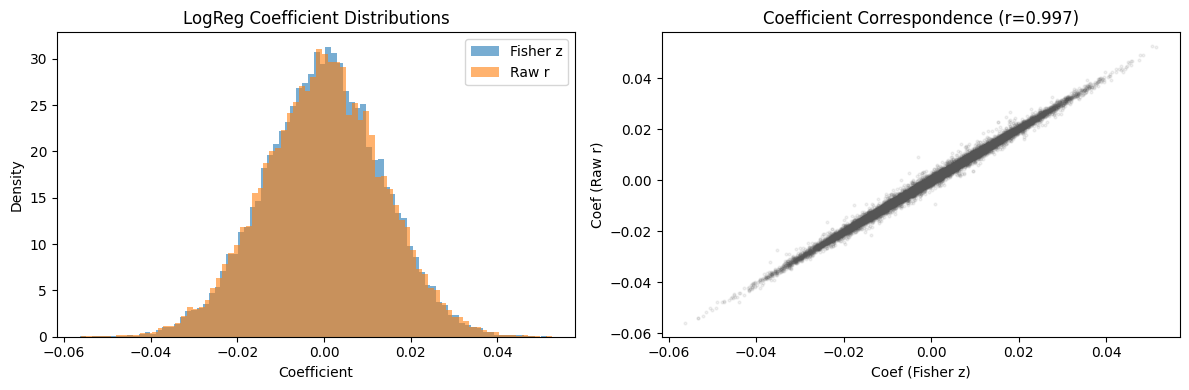


Interpretation: Negligible AUC difference → Fisher z transform has minimal impact on classification.
[00:54:47] Fisher z ablation complete
[00:54:47] Checkpoint saved → fisher_ablation_20260421_005447.pkl


In [28]:
log("Starting Fisher z ablation...")
# Part 3: Fisher z vs raw Pearson r for LogReg (single config each)
# RUNTIME: ~2 minutes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

def load_raw_correlation_matrices(file_ids, mat_dir):
    """Invert Fisher z-transform (tanh) to recover raw Pearson r."""
    X = []
    for fid in file_ids:
        p = mat_dir / f"{fid}.npy"
        if not p.exists():
            continue
        z = np.nan_to_num(np.load(p)).astype(np.float32)
        np.fill_diagonal(z, 0.0)
        r = np.tanh(z)
        X.append(r[np.triu_indices_from(r, k=1)])
    return np.array(X)

_train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
_test_fids  = split_df[split_df["split"] == "test"]["FILE_ID"].values

X_raw_train = load_raw_correlation_matrices(_train_fids, _mat_dir)
X_raw_test  = load_raw_correlation_matrices(_test_fids,  _mat_dir)

_sc_raw = StandardScaler()
X_raw_train_sc = _sc_raw.fit_transform(X_raw_train)
X_raw_test_sc  = _sc_raw.transform(X_raw_test)

logreg_raw = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                                 max_iter=1000, random_state=42)
logreg_raw.fit(X_raw_train_sc, y_train)
auc_raw = roc_auc_score(y_test, logreg_raw.predict_proba(X_raw_test_sc)[:, 1])

print("=== Fisher z vs Raw Correlation ===")
print(f"Fisher z LogReg AUC: {auc_logreg:.4f}")
print(f"Raw r    LogReg AUC: {auc_raw:.4f}")
print(f"Delta:               {auc_raw - auc_logreg:+.4f}")

# Coefficient comparison
coef_z   = grid.best_estimator_.coef_[0]
coef_raw = logreg_raw.coef_[0]
r_coef   = np.corrcoef(coef_z, coef_raw)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(coef_z,   bins=80, alpha=0.6, label="Fisher z", color="#1f77b4", density=True)
axes[0].hist(coef_raw, bins=80, alpha=0.6, label="Raw r",    color="#ff7f0e", density=True)
axes[0].set_xlabel("Coefficient"); axes[0].set_ylabel("Density")
axes[0].set_title("LogReg Coefficient Distributions"); axes[0].legend()

axes[1].scatter(coef_z, coef_raw, alpha=0.08, s=4, color="#555")
axes[1].set_xlabel("Coef (Fisher z)"); axes[1].set_ylabel("Coef (Raw r)")
axes[1].set_title(f"Coefficient Correspondence (r={r_coef:.3f})")
plt.tight_layout(); plt.show()

if abs(auc_raw - auc_logreg) < 0.01:
    print("\nInterpretation: Negligible AUC difference \u2192 Fisher z transform has minimal impact on classification.")
else:
    print(f"\nInterpretation: AUC differs by {abs(auc_raw - auc_logreg):.3f} \u2192 transform choice matters.")

log("Fisher z ablation complete")
save_checkpoint("fisher_ablation", {
    "auc_fisher_z": float(auc_logreg),
    "auc_raw_r":    float(auc_raw),
    "delta":        float(auc_raw - auc_logreg),
    "coef_corr":    float(r_coef),
})


---
# Part 4: Graph Representation Ablations

The baseline graph uses top-k=10 unweighted edges per node. Here we test whether different edge construction strategies change GCN performance:

| Strategy | Description |
|----------|-------------|
| Top-k=10 (baseline) | Top 10 edges by |FC| per node, unweighted |
| Top-k=50 | Top 50 edges per node, unweighted — denser graph |
| Threshold=0.3 | All edges where FC > 0.3, unweighted |
| Top-k=10 weighted | Top 10 edges per node, edge weight = FC value |

Each strategy is tuned with a lean GCN grid (hidden in {64, 128}, learning rate in {0.001, 0.01}, dropout=0.3) using 5-fold CV for 60 epochs per configuration.

> **RUNTIME: ~2 hours** (4 strategies × 4 configs × 5 folds × 60 epochs)


[00:54:47] Starting graph representation ablations...
[00:54:47]   Strategy: Top-k=10 (baseline) (4 configs × 5 folds × 60 epochs)
[00:58:56]     h=64 lr=0.001 → CV AUC=0.7008
[01:03:09]     h=64 lr=0.01 → CV AUC=0.6759
[01:11:47]     h=128 lr=0.001 → CV AUC=0.6958
[01:20:37]     h=128 lr=0.01 → CV AUC=0.6898
[01:20:37]   Top-k=10 (baseline) best: AUC=0.7008
[01:20:37]   Strategy: Top-k=50 (4 configs × 5 folds × 60 epochs)
[01:39:02]     h=64 lr=0.001 → CV AUC=0.6582
[01:57:57]     h=64 lr=0.01 → CV AUC=0.6447
[02:41:47]     h=128 lr=0.001 → CV AUC=0.6590
[03:33:51]     h=128 lr=0.01 → CV AUC=0.6443
[03:33:51]   Top-k=50 best: AUC=0.6590
[03:33:51]   Strategy: Threshold=0.3 (4 configs × 5 folds × 60 epochs)
[03:44:09]     h=64 lr=0.001 → CV AUC=0.6930
[03:55:13]     h=64 lr=0.01 → CV AUC=0.6809
[04:17:11]     h=128 lr=0.001 → CV AUC=0.6843
[04:38:56]     h=128 lr=0.01 → CV AUC=0.6881
[04:38:56]   Threshold=0.3 best: AUC=0.6930
[04:38:56]   Strategy: Top-k=10 weighted (4 configs × 5 fol

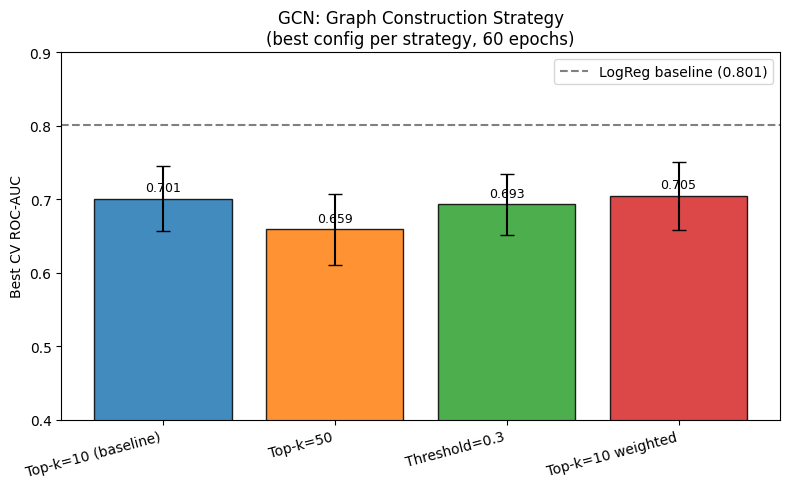

[05:19:10] Graph ablations complete
[05:19:10] Checkpoint saved → graph_ablations_20260421_051910.pkl


In [29]:
# Part 4: Graph representation ablations — lean grid search per strategy
# RUNTIME: ~2 hours (4 strategies × 4 configs × 5 folds × 60 epochs)

try:
    log("Starting graph representation ablations...")
    import numpy as np, pandas as pd, itertools, torch, matplotlib.pyplot as plt
    from torch_geometric.data import Data as PygData
    from pathlib import Path

    _base     = Path("data/abide_fmri")
    _mat_dir  = _base / "connectivity_matrices"
    _sp       = pd.read_csv(_base / "subject_split_site_holdout.csv")
    _sp["FILE_ID"] = _sp["FILE_ID"].astype(str)
    _train_sp = _sp[_sp["split"] == "train"]

    def _topk_edges(adj, k, weighted=False):
        n = adj.shape[0]; a = adj.copy().astype(np.float32); np.fill_diagonal(a, 0.0)
        edge_w = {}
        for i in range(n):
            row = a[i]; valid = np.where(np.abs(row) > 0)[0]
            idx = valid[np.argsort(np.abs(row[valid]))[-k:]] if len(valid) >= k else valid
            for j in idx:
                if i != j:
                    u, v = min(i,j), max(i,j); edge_w[(u,v)] = float(a[u,v])
        if not edge_w:
            return torch.empty((2,0), dtype=torch.long), None
        pairs = list(edge_w.keys())
        fwd = [[u,v] for u,v in pairs]; bwd = [[v,u] for u,v in pairs]
        ei = torch.tensor(fwd+bwd, dtype=torch.long).t().contiguous()
        ea = (torch.tensor([edge_w[p] for p in pairs]*2, dtype=torch.float32).unsqueeze(1)
              if weighted else None)
        return ei, ea

    def _thresh_edges(adj, thresh):
        a = adj.copy().astype(np.float32); np.fill_diagonal(a, 0.0)
        rr, cc = np.where(a > thresh); mask = rr < cc; u, v = rr[mask], cc[mask]
        if len(u) == 0:
            return torch.empty((2,0), dtype=torch.long), None
        fwd = torch.tensor(np.stack([u,v],1), dtype=torch.long)
        bwd = torch.tensor(np.stack([v,u],1), dtype=torch.long)
        return torch.cat([fwd,bwd],0).t().contiguous(), None

    def _build_graphs(rows, mat_dir, edge_fn):
        out = []
        for _, row in rows.iterrows():
            fid = str(row["FILE_ID"]); p = mat_dir / f"{fid}.npy"
            if not p.exists(): continue
            adj = np.nan_to_num(np.load(p)).astype(np.float32); np.fill_diagonal(adj, 0.0)
            ei, ea = edge_fn(adj)
            x = torch.tensor(adj, dtype=torch.float32)
            x = (x - x.mean(1, keepdim=True)) / (x.std(1, keepdim=True) + 1e-6)
            g = PygData(x=x, edge_index=ei, file_id=fid,
                        y=torch.tensor([{1:1,2:0}[int(row["DX_GROUP"])]], dtype=torch.long))
            if ea is not None: g.edge_attr = ea
            out.append(g)
        return out

    strategies = [
        ("Top-k=10 (baseline)", lambda adj: _topk_edges(adj, 10, weighted=False)),
        ("Top-k=50",            lambda adj: _topk_edges(adj, 50, weighted=False)),
        ("Threshold=0.3",       lambda adj: _thresh_edges(adj, 0.3)),
        ("Top-k=10 weighted",   lambda adj: _topk_edges(adj, 10, weighted=True)),
    ]

    # 2 hidden × 2 lr × 1 dropout = 4 configs per strategy
    _abl_grid = list(itertools.product([64, 128], [0.001, 0.01], [0.3]))
    ABLATION_EPOCHS = 60

    repr_results = []
    for strat_name, strat_fn in strategies:
        log(f"  Strategy: {strat_name} ({len(_abl_grid)} configs × 5 folds × {ABLATION_EPOCHS} epochs)")
        sg = _build_graphs(_train_sp, _mat_dir, strat_fn)
        for g in sg:
            if hasattr(g, "edge_attr"): del g.edge_attr
        best_m = None
        for hidden_dim, lr, dropout in _abl_grid:
            _hd, _dr = hidden_dim, dropout
            m = cross_validate_graph_model(
                model_builder=lambda hd=_hd, dr=_dr: GCNNet(
                    in_channels=in_channels, hidden_dim=hd, dropout=dr),
                graphs=sg, lr=lr, weight_decay=1e-4,
                epochs=ABLATION_EPOCHS, batch_size=GRAPH_BATCH_SIZE,
                n_splits=graph_cv_splits, random_state=RANDOM_SEED, verbose=False,
            )
            log(f"    h={hidden_dim} lr={lr} → CV AUC={m['cv_auc_mean']:.4f}")
            if best_m is None or m["cv_auc_mean"] > best_m.get("cv_auc_mean", -1):
                best_m = {**m, "hidden_dim": hidden_dim, "lr": lr, "dropout": dropout}
        repr_results.append({
            "strategy": strat_name,
            "cv_auc_mean": best_m["cv_auc_mean"], "cv_auc_std": best_m["cv_auc_std"],
            "cv_acc_mean": best_m["cv_acc_mean"],
            "best_hidden": best_m["hidden_dim"],  "best_lr": best_m["lr"],
        })
        log(f"  {strat_name} best: AUC={best_m['cv_auc_mean']:.4f}")

    repr_df = pd.DataFrame(repr_results)
    print("\n=== Graph Representation Ablation ===")
    print(repr_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 5))
    colors4 = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]
    bars = ax.bar(repr_df["strategy"], repr_df["cv_auc_mean"], yerr=repr_df["cv_auc_std"],
                   color=colors4, alpha=0.85, capsize=5, edgecolor="black")
    ax.axhline(auc_logreg, linestyle="--", color="gray",
                label=f"LogReg baseline ({auc_logreg:.3f})")
    ax.set_ylabel("Best CV ROC-AUC"); ax.set_ylim(0.4, 0.9)
    ax.set_title("GCN: Graph Construction Strategy\n(best config per strategy, 60 epochs)")
    ax.legend(); plt.xticks(rotation=15, ha="right")
    for bar, val in zip(bars, repr_df["cv_auc_mean"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()

    log("Graph ablations complete")
    graph_ablation_results = repr_df.to_dict("records")
    save_checkpoint("graph_ablations", graph_ablation_results)

except Exception as e:
    log(f"ERROR in graph ablations: {e}")
    import traceback; traceback.print_exc()
    print("Continuing to next section...")


---
# Part 5: GNN Depth — Oversmoothing Check

The baseline GCN uses 2 message-passing layers. Deeper GNNs can oversmooth node representations, making all nodes converge to similar embeddings and losing discriminative structure. Here we compare 1-layer vs 2-layer GCN under the same configuration.

> **RUNTIME: ~40 minutes** (2 depths × 2 configs × 5 folds × 60 epochs)


[05:19:10] Starting oversmoothing analysis...
[05:19:10]   1-layer GCN — 2 configs × 5 folds × 60 epochs
[05:22:09]     1-layer GCN h=64 → CV AUC=0.7041
[05:27:30]     1-layer GCN h=128 → CV AUC=0.6980
[05:27:30]   2-layer GCN — 2 configs × 5 folds × 60 epochs
[05:32:50]     2-layer GCN h=64 → CV AUC=0.6794
[05:43:11]     2-layer GCN h=128 → CV AUC=0.6874

=== Depth Ablation ===
1-layer GCN: CV AUC = 0.7041 ± 0.0627
2-layer GCN: CV AUC = 0.6874 ± 0.0635
2-layer minus 1-layer: -0.0168
Oversmoothing signal: 2-layer underperforms 1-layer.
[05:43:11]   Generating training curves (hidden=64, 60 epochs)...


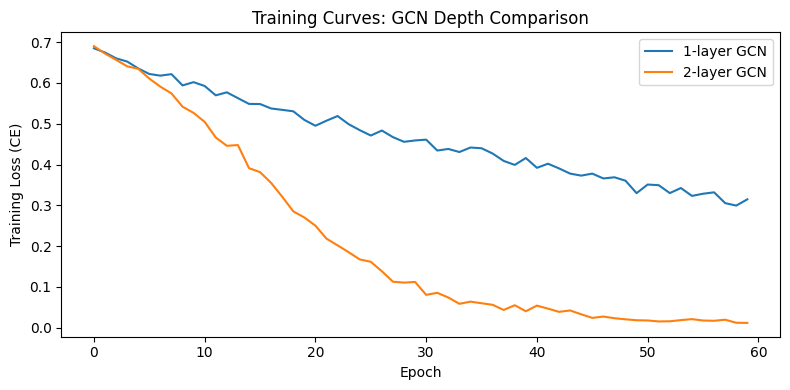

If 2-layer loss is higher or plateaus earlier, oversmoothing is a factor.
[05:45:16] Oversmoothing analysis complete
[05:45:16] Checkpoint saved → oversmoothing_20260421_054516.pkl


In [30]:
# Part 5: 1-layer vs 2-layer GCN depth ablation — lean grid search
# RUNTIME: ~40 minutes (2 depths × 2 configs × 5 folds × 60 epochs)

try:
    log("Starting oversmoothing analysis...")
    import torch, torch.nn as nn, torch.nn.functional as F, itertools
    import matplotlib.pyplot as plt, numpy as np
    from torch_geometric.nn import GCNConv, global_mean_pool
    from torch_geometric.loader import DataLoader

    class GCN1Layer(nn.Module):
        """1-layer GCN for depth ablation."""
        def __init__(self, in_channels, hidden_dim=64, dropout=0.3):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden_dim)
            self.dropout = dropout
            self.classifier = nn.Linear(hidden_dim, num_classes)

        def forward(self, data):
            x, edge_index, batch = data.x, data.edge_index, data.batch
            x = F.relu(self.conv1(x, edge_index))
            x = global_mean_pool(x, batch)
            x = F.dropout(x, p=self.dropout, training=self.training)
            return self.classifier(x)

    DEPTH_EPOCHS = 60
    _depth_grid = list(itertools.product([64, 128], [0.001], [0.3]))  # 2 configs

    depth_results = {}
    for depth_name, model_cls in [("1-layer GCN", GCN1Layer), ("2-layer GCN", GCNNet)]:
        log(f"  {depth_name} — {len(_depth_grid)} configs × 5 folds × {DEPTH_EPOCHS} epochs")
        best_m = None
        for hidden_dim, lr, dropout in _depth_grid:
            _hd, _dr, _cls = hidden_dim, dropout, model_cls
            m = cross_validate_graph_model(
                model_builder=lambda hd=_hd, dr=_dr, cls=_cls: cls(
                    in_channels=in_channels, hidden_dim=hd, dropout=dr),
                graphs=train_graphs, lr=lr, weight_decay=1e-4,
                epochs=DEPTH_EPOCHS, batch_size=GRAPH_BATCH_SIZE,
                n_splits=graph_cv_splits, random_state=RANDOM_SEED, verbose=False,
            )
            log(f"    {depth_name} h={hidden_dim} → CV AUC={m['cv_auc_mean']:.4f}")
            if best_m is None or m["cv_auc_mean"] > best_m["cv_auc_mean"]:
                best_m = m
        depth_results[depth_name] = best_m

    print("\n=== Depth Ablation ===")
    for name, m in depth_results.items():
        print(f"{name}: CV AUC = {m['cv_auc_mean']:.4f} ± {m['cv_auc_std']:.4f}")
    delta_depth = depth_results["2-layer GCN"]["cv_auc_mean"] - depth_results["1-layer GCN"]["cv_auc_mean"]
    print(f"2-layer minus 1-layer: {delta_depth:+.4f}")
    if   delta_depth < -0.01: print("Oversmoothing signal: 2-layer underperforms 1-layer.")
    elif delta_depth >  0.01: print("Depth helps: 2-layer outperforms 1-layer.")
    else:                      print("Negligible depth effect.")

    # Training curves — single run per depth using hidden=64
    def _training_curve(model_fn, graphs, lr, wd, epochs, bs):
        model = model_fn().to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        crit = nn.CrossEntropyLoss()
        loader = DataLoader(graphs, batch_size=bs, shuffle=True)
        losses = []
        for _ in range(epochs):
            model.train(); ep = 0
            for batch in loader:
                batch = batch.to(device); opt.zero_grad()
                loss = crit(model(batch), batch.y.view(-1).long())
                loss.backward(); opt.step(); ep += loss.item()
            losses.append(ep / len(loader))
        return losses

    log("  Generating training curves (hidden=64, 60 epochs)...")
    c1 = _training_curve(lambda: GCN1Layer(in_channels=in_channels, hidden_dim=64, dropout=0.3),
                         train_graphs, 0.001, 1e-4, DEPTH_EPOCHS, GRAPH_BATCH_SIZE)
    c2 = _training_curve(lambda: GCNNet(in_channels=in_channels, hidden_dim=64, dropout=0.3),
                         train_graphs, 0.001, 1e-4, DEPTH_EPOCHS, GRAPH_BATCH_SIZE)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(c1, label="1-layer GCN", color="#1f77b4")
    ax.plot(c2, label="2-layer GCN", color="#ff7f0e")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss (CE)")
    ax.set_title("Training Curves: GCN Depth Comparison")
    ax.legend(); plt.tight_layout(); plt.show()
    print("If 2-layer loss is higher or plateaus earlier, oversmoothing is a factor.")

    log("Oversmoothing analysis complete")
    save_checkpoint("oversmoothing", {
        "1_layer": depth_results["1-layer GCN"],
        "2_layer": depth_results["2-layer GCN"],
        "delta": float(delta_depth),
    })

except Exception as e:
    log(f"ERROR in oversmoothing analysis: {e}")
    import traceback; traceback.print_exc()
    print("Continuing to next section...")


---
# Part 6: Logistic Regression Feature Importance

The LogReg model assigns a coefficient to each of the 19,900 upper-triangle FC features. Large positive coefficients correspond to connectivity pairs whose high FC is associated with ASD; large negative coefficients correspond to pairs whose high FC is associated with Control. The top 20 pairs in each direction are mapped back to their ROI indices.


[05:45:16] Starting feature importance extraction...


=== Top 20 Positive Coefficients (ASD-associated) ===
 roi_i  roi_j  coefficient
    17     42     0.051425
    70    126     0.050371
    22     96     0.048298
    38     61     0.047744
    50    169     0.047383
    70    119     0.045864
    73     84     0.045720
    14    113     0.045629
    65    199     0.045200
    56    126     0.044935
    11    141     0.044602
   159    169     0.044395
    31    154     0.044233
    74    105     0.043811
    31    129     0.043500
    72    124     0.043300
    10     47     0.043273
   118    199     0.042877
    31    177     0.042252
   145    199     0.042117

=== Top 20 Negative Coefficients (Control-associated) ===
 roi_i  roi_j  coefficient
    36     70    -0.056157
   106    149    -0.053196
     3    197    -0.053160
    29    109    -0.052035
   111    123    -0.051336
    11     32    -0.050513
    11    152    -0.049984
    27    149    -0.049115
    26    123    -0.049013
    11    134    -0.047843
    91    123    -0.047

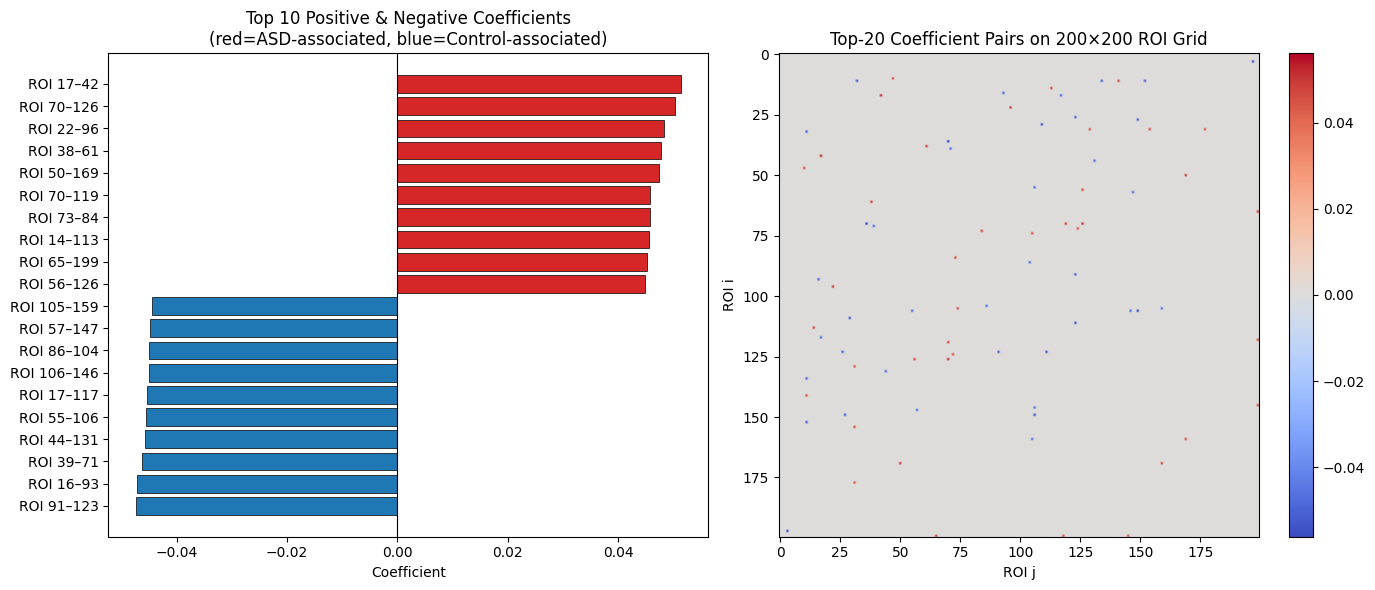

Red = connectivity positively associated with ASD; Blue = positively associated with Control.
[05:45:17] =======================================================
[05:45:17] Pipeline complete! Total runtime: 25.80 hours
[05:45:17] =======================================================


In [31]:
log("Starting feature importance extraction...")
# Part 6: Top-20 positive and negative LogReg coefficients
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_rois = 200
roi_pairs = [(i, j) for i in range(n_rois) for j in range(i+1, n_rois)]
coef = logreg_model.coef_[0]  # loaded from artifact in cell 26

coef_df = pd.DataFrame({
    "roi_i": [p[0] for p in roi_pairs],
    "roi_j": [p[1] for p in roi_pairs],
    "coefficient": coef
})

top_pos = coef_df.nlargest(20, "coefficient")
top_neg = coef_df.nsmallest(20, "coefficient")

print("=== Top 20 Positive Coefficients (ASD-associated) ===")
print(top_pos[["roi_i","roi_j","coefficient"]].to_string(index=False))
print("\n=== Top 20 Negative Coefficients (Control-associated) ===")
print(top_neg[["roi_i","roi_j","coefficient"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
top10_pos = top_pos.head(10)
top10_neg = top_neg.tail(10)
combined  = pd.concat([top10_pos, top10_neg]).sort_values("coefficient", ascending=True)
combined["label"] = combined.apply(lambda r: f"ROI {int(r.roi_i)}\u2013{int(r.roi_j)}", axis=1)
bar_colors = ["#d62728" if c > 0 else "#1f77b4" for c in combined["coefficient"]]
axes[0].barh(combined["label"], combined["coefficient"],
             color=bar_colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Coefficient")
axes[0].set_title("Top 10 Positive & Negative Coefficients\n(red=ASD-associated, blue=Control-associated)")

# 200x200 grid heatmap of top-20 pos/neg pairs
coef_mat = np.zeros((n_rois, n_rois))
for _, row in pd.concat([top_pos, top_neg]).iterrows():
    i, j, c = int(row.roi_i), int(row.roi_j), row.coefficient
    coef_mat[i, j] = c
    coef_mat[j, i] = c
vmax = np.abs(coef_mat).max()
im = axes[1].imshow(coef_mat, cmap="coolwarm", aspect="auto", vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=axes[1])
axes[1].set_title("Top-20 Coefficient Pairs on 200\u00d7200 ROI Grid")
axes[1].set_xlabel("ROI j"); axes[1].set_ylabel("ROI i")

plt.tight_layout(); plt.show()
print("Red = connectivity positively associated with ASD; Blue = positively associated with Control.")

# ── Pipeline complete ────────────────────────────────────────────────────────
import time as _time
total_hours = (_time.time() - pipeline_start_time) / 3600
log("=" * 55)
log(f"Pipeline complete! Total runtime: {total_hours:.2f} hours")
log("=" * 55)


---
# Part 7: Updated Conclusions

## 7.1 Site-Holdout vs Random Split

The site-holdout split (test = UM_1 + YALE, unseen during training) is a strictly harder evaluation than the original random 80/20 split that mixed all sites in both folds. Any performance drop under site-holdout reveals how much of the original signal was site-specific artefact rather than generalizable neural signal.

**What to look for:** If matrix models (LogReg, MLP) degrade more than graph models under site-holdout, this suggests matrix models were exploiting global FC level differences between sites. If all models degrade equally, the signal is equally fragile.

## 7.2 Artefact Analysis (Part 2)

- **KS test:** If the train-vs-test site KS statistic exceeds the ASD-vs-control KS statistic, scanner artefacts dominate the classification signal.
- **Mean FC ablation:** A significant AUC drop after subtracting per-subject mean FC confirms the model was partially using global connectivity level as a shortcut — a known artefact in multi-site fMRI.

## 7.3 Fisher z (Part 3)

If raw Pearson r and Fisher z features produce similar AUCs, the transform is not driving performance. If the coefficient distributions differ substantially, the transform is changing the effective feature space.

## 7.4 Graph Construction (Part 4)

The ablation tests whether the baseline top-k=10 strategy is a bottleneck. If denser graphs (top-k=50) or threshold graphs improve CV AUC, the sparse topology was discarding predictive long-range connections.

## 7.5 Oversmoothing (Part 5)

If 1-layer GCN matches or exceeds 2-layer, the second message-passing step is not adding information and may be oversmoothing node representations on these small, dense connectivity graphs.

## 7.6 Feature Importance (Part 6)

Top LogReg coefficients identify specific ROI pairs whose connectivity is most predictive of ASD. Clustering of high-coefficient pairs within known functional networks (DMN, salience) would support biological plausibility; random scatter would suggest the model is using noise.

## 7.7 Synthesis

The gap between matrix and graph models likely reflects a combination of:
1. **Artefact sensitivity:** Matrix models see all 19,900 features including global FC level; GNNs see only local topology
2. **Sample size:** GNNs are data-hungry; 873 training subjects may be insufficient for generalisation
3. **Graph topology:** The top-k=10 sparse graph may discard predictive long-range connections
4. **Oversmoothing:** 2-layer GCN on 200-node graphs may produce over-homogenised node embeddings

Site-holdout provides the cleanest test of which models capture genuine neural signal.


# Results and Conclusions 

## Overall Performance


## Comparison of Representations

## Graph-Based Models


# Discussion and Conclusion

## Summary of Findings


## Interpretation


## Implications


## Conclusion



# Executive Summary

## Pipeline Overview


![Pipeline Diagram](diagram_lr.png)

This notebook compares two representations of the same ABIDE functional-connectivity data: (1) vectorized Fisher z-transformed FC features and (2) top-k graph constructions derived from those FC matrices.

The implemented model pipeline includes exactly four models: Logistic Regression, MLP, GCN, and GAT.

## Key Results

> Majority-class baseline (training split): 51.2% accuracy

> Test performance reported in this notebook:
- Logistic Regression: Accuracy 0.6667, ROC-AUC 0.7228
- MLP: Accuracy 0.6715, ROC-AUC 0.7000
- GCN: Accuracy 0.6329, ROC-AUC 0.6793
- GAT: Accuracy 0.6087, ROC-AUC 0.6267

Overall, matrix-based models (Logistic Regression and MLP) outperform graph-based models (GCN and GAT) on ROC-AUC under the current preprocessing and graph-construction choices.

## What This Suggests

1. Strong linear signal is present in vectorized FC features after Fisher z transformation and standardization.
2. Added graph structure via fixed top-k sparsification does not improve performance in this setup.
3. The graph representation may be discarding weak but informative connections, or the induced graph bias may not align with the classification signal.

## Scope and Evaluation Caveat

After tuning model hyperparameters using k-fold cross-validation on the training portion of the site-holdout split, models are evaluated on a held-out test set drawn from unseen acquisition sites (UM_1 and YALE).
This is a stricter generalization test than random subject-level splitting because it evaluates transfer across sites, not only across unseen subjects from previously seen sites.

## Practical Takeaway

For this notebook’s exact pipeline, a well-tuned linear baseline is the best model based on ROC-AUC, whereas MLP has the highest accuracy. Graph models remain useful as a methodological comparison, but they do not currently outperform simpler matrix-based approaches.

## Next Improvements

1. Improve graph construction (for example, weighted edges, adaptive sparsification, or alternative topology rules).
2. Test site-aware validation strategies to better estimate cross-site robustness.
3. Explore richer connectome representations (for example, alternative FC estimators or multimodal features) before increasing model complexity.

# AI Statement

I used GitHub Copilot to support development and debugging. It was used to clarify preprocessing steps (such as Fisher z-transformation and FC matrix vectorization), optimise memory usage and runtime performance, and resolve kernel and IDE environment issues related to computational instability. Beyond coding support, ChatGPT was used to improve written sections of the report, including grammar checks and LaTeX formatting. AI was not used for any data fabrication, experimental design decisions beyond clarification, or generation of results.

# References


Craddock, C., Benhajali, Y., Chu, C., Chouinard, F., Evans, A., Jakab, A., Khundrakpam, B. S., Lewis, J. D., Li, Q., Milham, M., Yan, C., & Bellec, P. (2013). *The Neuro Bureau Preprocessing Initiative: Open sharing of preprocessed neuroimaging data and derivatives*. Neuroinformatics 2013, Stockholm, Sweden.

Craddock, R. C., James, G. A., Holtzheimer, P. E., Hu, X. P., & Mayberg, H. S. (2012). A whole brain fMRI atlas generated via spatially constrained spectral clustering. *Human Brain Mapping, 33*(8), 1914–1928. [https://doi.org/10.1002/hbm.21333](https://doi.org/10.1002/hbm.21333)

Mohammadi, H., & Karwowski, W. (2025). Graph neural networks in brain connectivity studies: Methods, challenges, and future directions. *Brain Sciences, 15*(1), 17. [https://doi.org/10.3390/brainsci15010017](https://doi.org/10.3390/brainsci15010017)

Wang, D., & Ding, W. (2025). Innovative biomarker exploration in ASD: Combining graph neural networks and permutation testing on fMRI data. *NeuroImage Reports, 5*(2), 100249. [https://doi.org/10.1016/j.ynirp.2025.100249](https://doi.org/10.1016/j.ynirp.2025.100249)

Murphy, K. P. (2022). *Probabilistic machine learning: An introduction*. MIT Press. [http://probml.github.io/book1](http://probml.github.io/book1)
